In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection

In [4]:
taxi_data = pd.read_csv("D:/bank-deposit-project/data/train.csv")
print('Data shape: {}'.format(taxi_data.shape))


Data shape: (1458644, 11)


In [5]:
taxi_data['pickup_datetime'] = pd.to_datetime(
    taxi_data['pickup_datetime'], 
    format='%Y-%m-%d %H:%M:%S'
)

print('Минимальная дата:', taxi_data['pickup_datetime'].min())
print('Максимальная дата:', taxi_data['pickup_datetime'].max())

Минимальная дата: 2016-01-01 00:00:17
Максимальная дата: 2016-06-30 23:59:39


In [6]:
# Суммарное количество пропусков по всем столбцам
total_missing = taxi_data.isnull().sum().sum()
print(f"Всего пропусков в данных: {total_missing}")

# Дополнительно — разбивка по столбцам
print("\nПропуски по столбцам:")
print(taxi_data.isnull().sum())

Всего пропусков в данных: 0

Пропуски по столбцам:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [7]:
# 1. Уникальные таксопарки
print("1. Уникальных таксопарков:", taxi_data['vendor_id'].nunique())

# 2. Максимальное количество пассажиров
print("2. Максимальное количество пассажиров:", taxi_data['passenger_count'].max())

# 3. Средняя и медианная длительность
print(f"3. Среднее время поездки:   {taxi_data['trip_duration'].mean():.0f} сек")
print(f"   Медианное время поездки: {taxi_data['trip_duration'].median():.0f} сек")

# 4. Минимальное и максимальное время поездки
print(f"4. Минимальное время поездки: {taxi_data['trip_duration'].min()} сек")
print(f"   Максимальное время поездки: {taxi_data['trip_duration'].max()} сек")

1. Уникальных таксопарков: 2
2. Максимальное количество пассажиров: 9
3. Среднее время поездки:   959 сек
   Медианное время поездки: 662 сек
4. Минимальное время поездки: 1 сек
   Максимальное время поездки: 3526282 сек


In [8]:
def add_datetime_features(df):
    """
    Добавляет временные признаки в таблицу с поездками.
    
    Параметры:
    -----------
    df : pd.DataFrame
        Таблица с данными о поездках (должен быть столбец pickup_datetime)
    
    Возвращает:
    -----------
    pd.DataFrame
        Та же таблица с добавленными столбцами:
        - pickup_date: дата начала поездки (без времени)
        - pickup_hour: час начала поездки
        - pickup_day_of_week: день недели начала поездки (0=Пн, 6=Вс)
    """
    # Делаем копию, чтобы не менять исходный df
    df = df.copy()
    
    # Преобразуем в datetime (если ещё не сделано)
    df['pickup_datetime'] = pd.to_datetime(
        df['pickup_datetime'], 
        format='%Y-%m-%d %H:%M:%S'
    )
    
    # Добавляем признаки
    df['pickup_date'] = df['pickup_datetime'].dt.date
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek
    
    return df

In [9]:
taxi_data = add_datetime_features(taxi_data)
print("Новые столбцы:", ['pickup_date', 'pickup_hour', 'pickup_day_of_week'])
print(taxi_data[['pickup_datetime', 'pickup_date', 'pickup_hour', 'pickup_day_of_week']].head())

Новые столбцы: ['pickup_date', 'pickup_hour', 'pickup_day_of_week']
      pickup_datetime pickup_date  pickup_hour  pickup_day_of_week
0 2016-03-14 17:24:55  2016-03-14           17                   0
1 2016-06-12 00:43:35  2016-06-12            0                   6
2 2016-01-19 11:35:24  2016-01-19           11                   1
3 2016-04-06 19:32:31  2016-04-06           19                   2
4 2016-03-26 13:30:55  2016-03-26           13                   5


In [10]:
# Сколько поездок в субботу (dayofweek == 5)
saturday_rides = (taxi_data['pickup_day_of_week'] == 5).sum()
print(f"Поездок в субботу: {saturday_rides}")

Поездок в субботу: 220868


In [11]:
# Сколько уникальных дат в данных
n_days = taxi_data['pickup_date'].nunique()
print(f"Уникальных дней: {n_days}")

# Среднее число поездок в день
avg_per_day = len(taxi_data) / n_days
print(f"Среднее число поездок в день: {avg_per_day:.0f}")

Уникальных дней: 182
Среднее число поездок в день: 8015


In [15]:

holidays = pd.read_csv("D:/bank-deposit-project/data/holiday_data.csv", sep=';')

print(holidays.head())
print("\nСтолбцы:", holidays.columns.tolist())
print("Форма:", holidays.shape)

      day        date                     holiday
0  Friday  2016-01-01               New Years Day
1  Monday  2016-01-18  Martin Luther King Jr. Day
2  Friday  2016-02-12          Lincoln's Birthday
3  Monday  2016-02-15             Presidents' Day
4  Sunday  2016-05-08                Mother's Day

Столбцы: ['day', 'date', 'holiday']
Форма: (14, 3)


In [16]:
def add_holiday_features(taxi_df, holidays_df):
    """
    Добавляет признак pickup_holiday — является ли день праздничным.
    
    Параметры:
    -----------
    taxi_df : pd.DataFrame
        Таблица с поездками (должен быть столбец pickup_date)
    holidays_df : pd.DataFrame
        Таблица с праздниками (столбец date)
    
    Возвращает:
    -----------
    pd.DataFrame
        Обновлённая таблица с новым столбцом pickup_holiday (1 — праздник, 0 — нет)
    """
    df = taxi_df.copy()
    
    # Приводим даты к одному типу
    df['pickup_date'] = pd.to_datetime(df['pickup_date'])
    holidays_df['date'] = pd.to_datetime(holidays_df['date'])
    
    # Множество праздничных дат для быстрой проверки
    holiday_dates = set(holidays_df['date'].dt.date)
    
    # Бинарный признак: 1 — если pickup_date в списке праздников, 0 — иначе
    df['pickup_holiday'] = df['pickup_date'].dt.date.isin(holiday_dates).astype(int)
    
    return df

In [17]:
taxi_data = add_holiday_features(taxi_data, holidays)

# Проверка
print("Распределение pickup_holiday:")
print(taxi_data['pickup_holiday'].value_counts())
print(f"\nПоездок в праздничные дни: {taxi_data['pickup_holiday'].sum()}")

Распределение pickup_holiday:
0    1407522
1      51122
Name: pickup_holiday, dtype: int64

Поездок в праздничные дни: 51122


In [18]:
# Медианная длительность поездки в праздничные дни
holiday_trips = taxi_data[taxi_data['pickup_holiday'] == 1]
median_holiday = holiday_trips['trip_duration'].median()
print(f"Медианная длительность поездки в праздники: {median_holiday:.0f} сек")

Медианная длительность поездки в праздники: 585 сек


In [19]:
# Скачай файл OSRM по ссылке из задания, потом загрузи
osrm_data = pd.read_csv("D:/bank-deposit-project/data/osrm_data_train.csv")
print("Форма OSRM:", osrm_data.shape)
print("\nСтолбцы:", osrm_data.columns.tolist())
print("\nПервые строки:")
print(osrm_data.head())

Форма OSRM: (1458643, 12)

Столбцы: ['id', 'starting_street', 'end_street', 'total_distance', 'total_travel_time', 'number_of_steps', 'street_for_each_step', 'distance_per_step', 'travel_time_per_step', 'step_maneuvers', 'step_direction', 'step_location_list']

Первые строки:
          id   starting_street              end_street  total_distance  \
0  id2875421   Columbus Circle        East 65th Street          2009.1   
1  id2377394        2nd Avenue  Washington Square West          2513.2   
2  id3504673  Greenwich Street                Broadway          1779.4   
3  id2181028          Broadway        West 81st Street          1614.9   
4  id0801584  Lexington Avenue        West 31st Street          1393.5   

   total_travel_time  number_of_steps  \
0              164.9                5   
1              332.0                6   
2              235.8                4   
3              140.1                5   
4              189.4                5   

                               

In [20]:
def add_osrm_features(taxi_df, osrm_df):
    """
    Добавляет к таблице с поездками данные из OSRM.
    
    Параметры:
    -----------
    taxi_df : pd.DataFrame
        Таблица с поездками
    osrm_df : pd.DataFrame
        Таблица с данными OSRM
    
    Возвращает:
    -----------
    pd.DataFrame
        Обновлённая таблица с тремя новыми столбцами:
        total_distance, total_travel_time, number_of_steps
    """
    # Выделяем нужные столбцы
    osrm_subset = osrm_df[['id', 'total_distance', 'total_travel_time', 'number_of_steps']]
    
    # Left join по id
    merged = taxi_df.merge(osrm_subset, on='id', how='left')
    
    return merged


taxi_data = add_osrm_features(taxi_data, osrm_data)

print("Форма после merge:", taxi_data.shape)
print("\nПропуски в новых столбцах:")
print(taxi_data[['total_distance', 'total_travel_time', 'number_of_steps']].isnull().sum())

Форма после merge: (1458644, 18)

Пропуски в новых столбцах:
total_distance       1
total_travel_time    1
number_of_steps      1
dtype: int64


In [21]:
median_actual = taxi_data['trip_duration'].median()
median_osrm = taxi_data['total_travel_time'].median()

print(f"Медиана trip_duration:      {median_actual:.0f} сек")
print(f"Медиана total_travel_time:  {median_osrm:.0f} сек")
print(f"Разница:                    {median_actual - median_osrm:.0f} сек")

Медиана trip_duration:      662 сек
Медиана total_travel_time:  290 сек
Разница:                    372 сек


In [22]:
# Количество строк, где есть хотя бы один пропуск в OSRM-столбцах
rows_with_missing = taxi_data[['total_distance', 'total_travel_time', 'number_of_steps']].isnull().any(axis=1).sum()
print(f"Строк с пропусками: {rows_with_missing}")

Строк с пропусками: 1


In [23]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус Земли в километрах
    EARTH_RADIUS = 6371
    # считаем кратчайшее расстояние h по формуле гаверсинуса
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h


def get_angle_direction(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

In [24]:
def add_geographical_features(df):
    """
    Добавляет географические признаки в таблицу с поездками.
    
    Параметры:
    -----------
    df : pd.DataFrame
        Таблица с поездками (нужны столбцы pickup_latitude, pickup_longitude,
        dropoff_latitude, dropoff_longitude)
    
    Возвращает:
    -----------
    pd.DataFrame
        Обновлённая таблица с двумя новыми столбцами:
        - haversine_distance: расстояние по формуле гаверсинуса (в км)
        - direction: направление движения (в градусах)
    """
    df = df.copy()
    
    df['haversine_distance'] = get_haversine_distance(
        df['pickup_latitude'].values,
        df['pickup_longitude'].values,
        df['dropoff_latitude'].values,
        df['dropoff_longitude'].values
    )
    
    df['direction'] = get_angle_direction(
        df['pickup_latitude'].values,
        df['pickup_longitude'].values,
        df['dropoff_latitude'].values,
        df['dropoff_longitude'].values
    )
    
    return df


taxi_data = add_geographical_features(taxi_data)

print("Новые столбцы добавлены:")
print(taxi_data[['haversine_distance', 'direction']].describe())

Новые столбцы добавлены:
       haversine_distance     direction
count        1.458644e+06  1.458644e+06
mean         3.440864e+00 -1.566892e+01
std          4.296538e+00  1.044915e+02
min          0.000000e+00 -1.799927e+02
25%          1.231837e+00 -1.252736e+02
50%          2.093717e+00  8.199996e+00
75%          3.875337e+00  5.340495e+01
max          1.240909e+03  1.800000e+02


In [25]:
median_haversine = taxi_data['haversine_distance'].median()
print(f"Медианное расстояние по гаверсинусу: {median_haversine:.2f} км")

Медианное расстояние по гаверсинусу: 2.09 км


In [26]:
import numpy as np
import pandas as pd
from sklearn import cluster


# ============================================================
# 1. Создаём обучающую выборку из географических координат
# ============================================================
coords = np.hstack((
    taxi_data[['pickup_latitude', 'pickup_longitude']],
    taxi_data[['dropoff_latitude', 'dropoff_longitude']]
))

# ============================================================
# 2. Обучаем K-Means на 10 кластерах
# ============================================================
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)


# ============================================================
# 3. Функция добавления кластерных признаков
# ============================================================
def add_cluster_features(df, kmeans_model):
    """
    Добавляет признак geo_cluster — номер географического кластера
    для каждой поездки (на основе координат старта и финиша).
    
    Параметры:
    -----------
    df : pd.DataFrame
        Таблица с поездками
    kmeans_model : KMeans
        Обученная модель K-Means
    
    Возвращает:
    -----------
    pd.DataFrame
        Обновлённая таблица со столбцом geo_cluster
    """
    df = df.copy()
    
    # Формируем матрицу координат для предсказания
    coords_to_predict = np.hstack((
        df[['pickup_latitude', 'pickup_longitude']],
        df[['dropoff_latitude', 'dropoff_longitude']]
    ))
    
    # Предсказываем кластер для каждой поездки
    df['geo_cluster'] = kmeans_model.predict(coords_to_predict)
    
    return df


# ============================================================
# 4. Применяем функцию к таблице
# ============================================================
taxi_data = add_cluster_features(taxi_data, kmeans)


# ============================================================
# 5. Проверяем распределение поездок по кластерам
# ============================================================
cluster_counts = taxi_data['geo_cluster'].value_counts().sort_index()
print("Распределение поездок по кластерам:")
print(cluster_counts)
print(f"\nВсего кластеров: {taxi_data['geo_cluster'].nunique()}")


# ============================================================
# 6. Наименьший кластер
# ============================================================
min_cluster_size = cluster_counts.min()
min_cluster_id = cluster_counts.idxmin()

print(f"\nНаименьший кластер: №{min_cluster_id}")
print(f"Количество поездок в нём: {min_cluster_size}")

Распределение поездок по кластерам:
0    595850
1         2
2     32769
3     40671
4         4
5         3
6    405045
7     45791
8     15510
9    322999
Name: geo_cluster, dtype: int64

Всего кластеров: 10

Наименьший кластер: №1
Количество поездок в нём: 2


In [28]:
print("Столбцы в weather_data:")
print(weather_data.columns.tolist())

Столбцы в weather_data:
['time', 'temperature', 'windchill', 'heat index', 'humidity', 'pressure', 'dew Point', 'visibility', 'wind dir', 'wind speed', 'gust speed', 'precip', 'events', 'conditions', 'date', 'hour']


In [29]:
import pandas as pd


# ============================================================
# 1. Загружаем данные о погоде
# ============================================================
weather_data = pd.read_csv("D:/bank-deposit-project/data/weather_data.csv")
print("Форма данных о погоде:", weather_data.shape)
print("Столбцы:", weather_data.columns.tolist())


# ============================================================
# 2. Функция добавления погодных признаков
# ============================================================
def add_weather_features(taxi_df, weather_df):
    """
    Добавляет к таблице с поездками погодные признаки.
    """
    df = taxi_df.copy()
    wdf = weather_df.copy()
    
    # --- Нормализуем названия столбцов (пробелы → подчёркивания, нижний регистр) ---
    wdf.columns = [
        c.strip().lower().replace(' ', '_').replace('.', '_') 
        for c in wdf.columns
    ]
    print("\nНормализованные столбцы погоды:", wdf.columns.tolist())
    
    # --- Оставляем только нужные столбцы ---
    # ВАЖНО: у нас уже есть date и hour в weather_data — используем их напрямую!
    weather_cols = ['date', 'hour', 'temperature', 'visibility', 'wind_speed', 'precip', 'events']
    weather_subset = wdf[weather_cols].copy()
    
    # --- Приводим date к типу date ---
    weather_subset['date'] = pd.to_datetime(weather_subset['date']).dt.date
    
    # --- Приводим pickup_date к типу date ---
    df['pickup_date'] = pd.to_datetime(df['pickup_date']).dt.date
    
    # --- Объединяем по дате и часу ---
    merged = df.merge(
        weather_subset,
        left_on=['pickup_date', 'pickup_hour'],
        right_on=['date', 'hour'],
        how='left'
    )
    
    # --- Удаляем вспомогательные столбцы date и hour ---
    merged = merged.drop(columns=['date', 'hour'], errors='ignore')
    
    return merged


# ============================================================
# 3. Применяем функцию
# ============================================================
taxi_data = add_weather_features(taxi_data, weather_data)

print("\nФорма после merge:", taxi_data.shape)
print("\nНовые столбцы:", [c for c in taxi_data.columns if c in 
      ['temperature', 'visibility', 'wind_speed', 'precip', 'events']])

print("\nПропуски в погодных столбцах:")
print(taxi_data[['temperature', 'visibility', 'wind_speed', 'precip', 'events']].isnull().sum())


# ============================================================
# 4. Сколько поездок в снежную погоду?
# ============================================================
snow_rides = (taxi_data['events'] == 'Snow').sum()
print(f"\nПоездок в снежную погоду: {snow_rides}")

print("\nРаспределение поездок по погодным явлениям:")
print(taxi_data['events'].value_counts(dropna=False))

Форма данных о погоде: (8787, 16)
Столбцы: ['time', 'temperature', 'windchill', 'heat index', 'humidity', 'pressure', 'dew Point', 'visibility', 'wind dir', 'wind speed', 'gust speed', 'precip', 'events', 'conditions', 'date', 'hour']

Нормализованные столбцы погоды: ['time', 'temperature', 'windchill', 'heat_index', 'humidity', 'pressure', 'dew_point', 'visibility', 'wind_dir', 'wind_speed', 'gust_speed', 'precip', 'events', 'conditions', 'date', 'hour']

Форма после merge: (1458644, 26)

Новые столбцы: ['temperature', 'visibility', 'wind_speed', 'precip', 'events']

Пропуски в погодных столбцах:
temperature    12032
visibility     12032
wind_speed     12032
precip         12032
events         12032
dtype: int64

Поездок в снежную погоду: 13126

Распределение поездок по погодным явлениям:
None    1375185
Rain      58300
Snow      13126
NaN       12032
Fog           1
Name: events, dtype: int64


In [30]:
# Общее количество наблюдений
total_rows = len(taxi_data)
print(f"Всего строк: {total_rows}")

# Пропуски в погодных столбцах
weather_cols = ['temperature', 'visibility', 'wind_speed', 'precip', 'events']
missing_counts = taxi_data[weather_cols].isnull().sum()
print("\nПропуски по столбцам:")
print(missing_counts)

# Считаем долю пропусков
# Вариант 1: суммарно по всем погодным столбцам (сумма всех NaN)
total_missing_cells = taxi_data[weather_cols].isnull().sum().sum()
total_cells = total_rows * len(weather_cols)
share_1 = total_missing_cells / total_cells * 100
print(f"\nВариант 1 — доля от всех ячеек:")
print(f"{share_1:.2f}%")

# Вариант 2: доля строк, где есть хотя бы один пропуск
rows_with_missing = taxi_data[weather_cols].isnull().any(axis=1).sum()
share_2 = rows_with_missing / total_rows * 100
print(f"\nВариант 2 — доля строк с хотя бы одним пропуском:")
print(f"{share_2:.2f}%")

# Вариант 3: доля пропусков в конкретном столбце (например, events)
share_3 = taxi_data['events'].isnull().sum() / total_rows * 100
print(f"\nВариант 3 — доля пропусков в столбце 'events':")
print(f"{share_3:.2f}%")

Всего строк: 1458644

Пропуски по столбцам:
temperature    12032
visibility     12032
wind_speed     12032
precip         12032
events         12032
dtype: int64

Вариант 1 — доля от всех ячеек:
0.82%

Вариант 2 — доля строк с хотя бы одним пропуском:
0.82%

Вариант 3 — доля пропусков в столбце 'events':
0.82%


In [31]:
import pandas as pd
import numpy as np


# ============================================================
# Функция заполнения пропусков
# ============================================================
def fill_null_weather_data(df):
    """
    Заполняет пропуски в погодных столбцах и OSRM-столбцах.
    
    Параметры:
    -----------
    df : pd.DataFrame
        Таблица с поездками
    
    Возвращает:
    -----------
    pd.DataFrame
        Таблица с заполненными пропусками
    """
    df = df.copy()
    
    # --- 1. Погодные столбцы: заполняем медианой по дате ---
    weather_cols = ['temperature', 'visibility', 'wind_speed', 'precip']
    
    for col in weather_cols:
        df[col] = df[col].fillna(
            df.groupby('pickup_date')[col].transform('median')
        )
    
    # --- 2. events: заполняем строкой 'None' ---
    df['events'] = df['events'].fillna('None')
    
    # --- 3. OSRM-столбцы: заполняем общей медианой ---
    osrm_cols = ['total_distance', 'total_travel_time', 'number_of_steps']
    
    for col in osrm_cols:
        df[col] = df[col].fillna(df[col].median())
    
    return df


# ============================================================
# Применяем функцию
# ============================================================
taxi_data = fill_null_weather_data(taxi_data)


# ============================================================
# Проверка: сколько пропусков осталось
# ============================================================
print("Пропуски после заполнения:")
print(taxi_data[['temperature', 'visibility', 'wind_speed', 'precip', 'events',
                 'total_distance', 'total_travel_time', 'number_of_steps']].isnull().sum())


# ============================================================
# Ответ на вопрос: медиана temperature
# ============================================================
median_temp = taxi_data['temperature'].median()
print(f"\nМедиана temperature после заполнения: {median_temp:.1f}")

Пропуски после заполнения:
temperature          0
visibility           0
wind_speed           0
precip               0
events               0
total_distance       0
total_travel_time    0
number_of_steps      0
dtype: int64

Медиана temperature после заполнения: 11.1


In [32]:
import pandas as pd
import numpy as np


# ============================================================
# 1. Удаляем поездки длительностью более 24 часов
# ============================================================
print("=" * 60)
print("ШАГ 1: Удаление поездок длительностью > 24 часов")
print("=" * 60)

# 24 часа в секундах
MAX_DURATION = 24 * 60 * 60  # 86400 секунд

# Сколько таких поездок
long_rides = taxi_data[taxi_data['trip_duration'] > MAX_DURATION]
print(f"Поездок длительностью > 24 часов: {len(long_rides)}")

# Удаляем
taxi_data = taxi_data[taxi_data['trip_duration'] <= MAX_DURATION].copy()
print(f"Размер после удаления: {taxi_data.shape}")


# ============================================================
# 2. Удаляем поездки со средней скоростью > 300 км/ч
# ============================================================
print("\n" + "=" * 60)
print("ШАГ 2: Удаление поездок со скоростью > 300 км/ч")
print("=" * 60)

# Средняя скорость = расстояние (км) / время (часы)
# total_distance в метрах → переводим в км
# trip_duration в секундах → переводим в часы

taxi_data['avg_speed'] = (
    taxi_data['total_distance'] / 1000  # км
) / (
    taxi_data['trip_duration'] / 3600   # часы
)

# Сколько поездок со скоростью > 300 км/ч
fast_rides = taxi_data[taxi_data['avg_speed'] > 300]
print(f"Поездок со скоростью > 300 км/ч: {len(fast_rides)}")

# Удаляем
taxi_data = taxi_data[taxi_data['avg_speed'] <= 300].copy()
print(f"Размер после удаления: {taxi_data.shape}")


# ============================================================
# 3. Проверка
# ============================================================
print("\n" + "=" * 60)
print("ИТОГ")
print("=" * 60)
print(f"Максимальная длительность: {taxi_data['trip_duration'].max():.0f} сек "
      f"({taxi_data['trip_duration'].max()/3600:.2f} ч)")
print(f"Максимальная скорость:     {taxi_data['avg_speed'].max():.1f} км/ч")
print(f"Финальный размер:          {taxi_data.shape}")

ШАГ 1: Удаление поездок длительностью > 24 часов
Поездок длительностью > 24 часов: 4
Размер после удаления: (1458640, 26)

ШАГ 2: Удаление поездок со скоростью > 300 км/ч
Поездок со скоростью > 300 км/ч: 407
Размер после удаления: (1458233, 27)

ИТОГ
Максимальная длительность: 86392 сек (24.00 ч)
Максимальная скорость:     298.7 км/ч
Финальный размер:          (1458233, 27)


Статистики trip_duration_log:
count    1.458233e+06
mean     6.468126e+00
std      7.924706e-01
min      6.931472e-01
25%      5.986452e+00
50%      6.498282e+00
75%      6.981006e+00
max      1.136666e+01
Name: trip_duration_log, dtype: float64


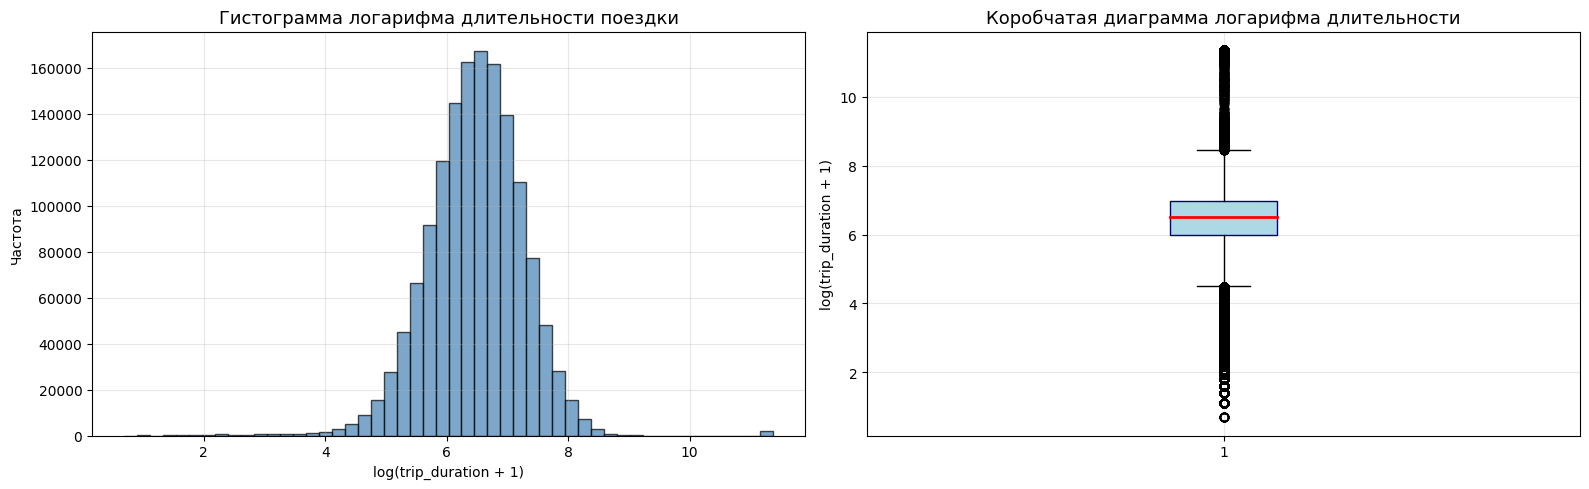


Тест Д'Агостино-Пирсона:
  statistic = 877.31
  p-value   = 3.12e-191
  p-value (округлённо до 2 знаков) = 0.00

Т.к. p-value (3.12e-191) < α (0.05), нулевая гипотеза отвергается.
→ Распределение ОТЛИЧНО от нормального.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# ============================================================
# 1. Логарифмируем целевую переменную
# ============================================================
taxi_data['trip_duration_log'] = np.log(taxi_data['trip_duration'] + 1)

print("Статистики trip_duration_log:")
print(taxi_data['trip_duration_log'].describe())


# ============================================================
# 2. Гистограмма + коробчатая диаграмма
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Гистограмма ---
axes[0].hist(
    taxi_data['trip_duration_log'],
    bins=50,
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)
axes[0].set_title('Гистограмма логарифма длительности поездки', fontsize=13)
axes[0].set_xlabel('log(trip_duration + 1)')
axes[0].set_ylabel('Частота')
axes[0].grid(alpha=0.3)

# --- Коробчатая диаграмма ---
axes[1].boxplot(
    taxi_data['trip_duration_log'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Коробчатая диаграмма логарифма длительности', fontsize=13)
axes[1].set_ylabel('log(trip_duration + 1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Тест Д’Агостино-Пирсона на нормальность
# ============================================================
# Берём выборку (тест не рассчитан на 1.5 млн наблюдений — можно взять срез)
sample = taxi_data['trip_duration_log'].sample(10000, random_state=42)

stat, p_value = stats.normaltest(sample)

print(f"\nТест Д'Агостино-Пирсона:")
print(f"  statistic = {stat:.2f}")
print(f"  p-value   = {p_value:.2e}")
print(f"  p-value (округлённо до 2 знаков) = {p_value:.2f}")


# ============================================================
# 4. Интерпретация
# ============================================================
alpha = 0.05
if p_value < alpha:
    print(f"\nТ.к. p-value ({p_value:.2e}) < α ({alpha}), "
          f"нулевая гипотеза отвергается.")
    print("→ Распределение ОТЛИЧНО от нормального.")
else:
    print(f"\nТ.к. p-value ({p_value:.2e}) >= α ({alpha}), "
          f"нет оснований отвергнуть нулевую гипотезу.")
    print("→ Распределение можно считать нормальным.")

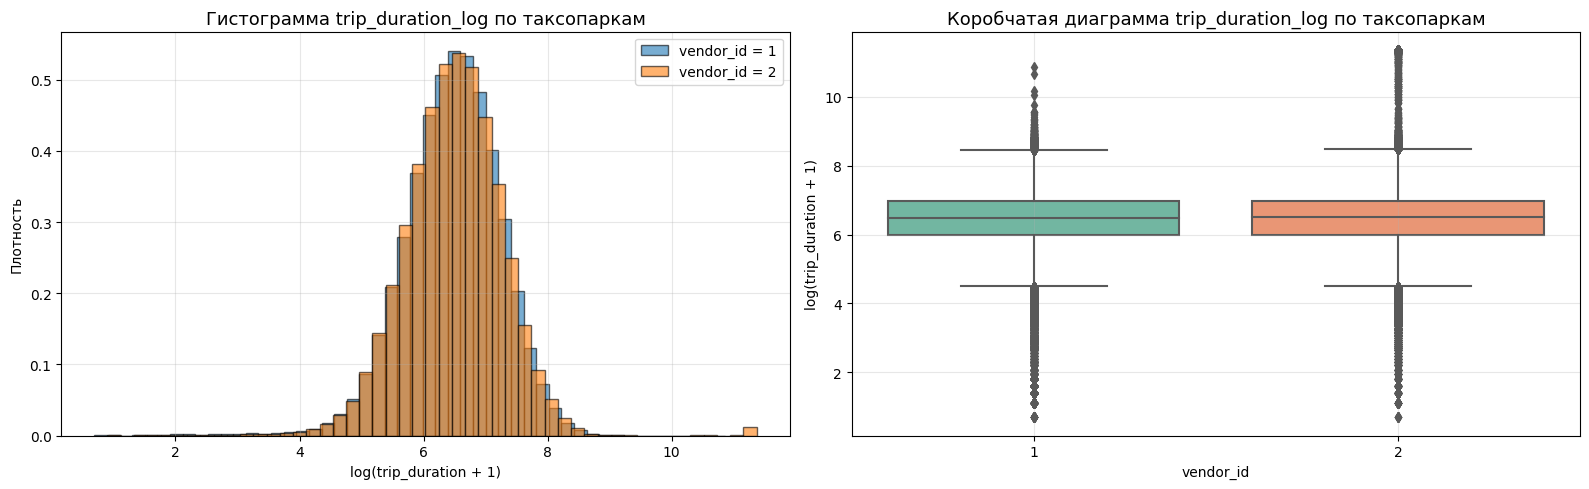

Статистики trip_duration_log по vendor_id:
               mean      50%       std
vendor_id                             
1          6.451452  6.49224  0.783984
2          6.482619  6.50279  0.799493

Медианы trip_duration по vendor_id (в секундах):
vendor_id
1    659.0
2    666.0
Name: trip_duration, dtype: float64


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Гистограмма: распределение trip_duration_log по vendor_id
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Гистограмма ---
for vendor in sorted(taxi_data['vendor_id'].unique()):
    subset = taxi_data[taxi_data['vendor_id'] == vendor]['trip_duration_log']
    axes[0].hist(
        subset,
        bins=50,
        alpha=0.6,
        label=f'vendor_id = {vendor}',
        density=True,
        edgecolor='black'
    )

axes[0].set_title('Гистограмма trip_duration_log по таксопаркам', fontsize=13)
axes[0].set_xlabel('log(trip_duration + 1)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Коробчатая диаграмма ---
sns.boxplot(
    data=taxi_data,
    x='vendor_id',
    y='trip_duration_log',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Коробчатая диаграмма trip_duration_log по таксопаркам', fontsize=13)
axes[1].set_xlabel('vendor_id')
axes[1].set_ylabel('log(trip_duration + 1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. Числовое сравнение (для подстраховки)
# ============================================================
print("Статистики trip_duration_log по vendor_id:")
print(taxi_data.groupby('vendor_id')['trip_duration_log'].describe()[['mean', '50%', 'std']])

print("\nМедианы trip_duration по vendor_id (в секундах):")
print(taxi_data.groupby('vendor_id')['trip_duration'].median())

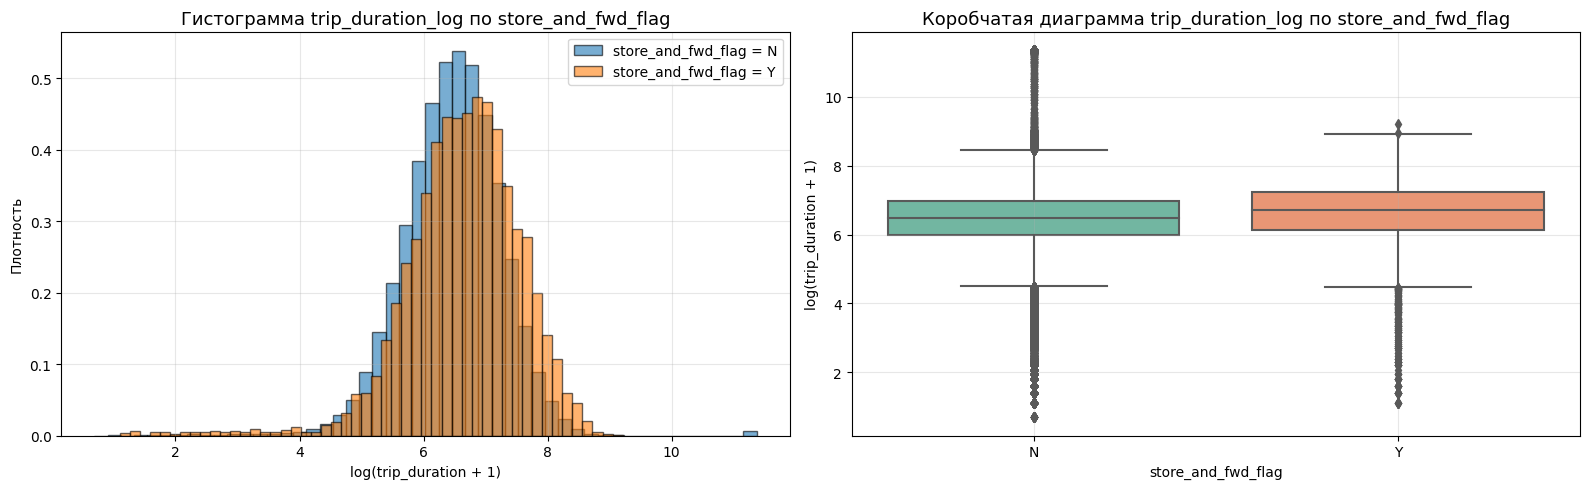

Статистики trip_duration_log по store_and_fwd_flag:
                        count     mean       50%       std
store_and_fwd_flag                                        
N                   1450192.0  6.46721  6.496775  0.791476
Y                      8041.0  6.63329  6.701960  0.940689

Медианы trip_duration (в секундах):
store_and_fwd_flag
N    662.0
Y    813.0
Name: trip_duration, dtype: float64


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Визуализация: распределение trip_duration_log
#    в зависимости от store_and_fwd_flag
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Гистограмма ---
for flag in sorted(taxi_data['store_and_fwd_flag'].unique()):
    subset = taxi_data[taxi_data['store_and_fwd_flag'] == flag]['trip_duration_log']
    axes[0].hist(
        subset,
        bins=50,
        alpha=0.6,
        label=f'store_and_fwd_flag = {flag}',
        density=True,
        edgecolor='black'
    )

axes[0].set_title('Гистограмма trip_duration_log по store_and_fwd_flag', fontsize=13)
axes[0].set_xlabel('log(trip_duration + 1)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Коробчатая диаграмма ---
sns.boxplot(
    data=taxi_data,
    x='store_and_fwd_flag',
    y='trip_duration_log',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Коробчатая диаграмма trip_duration_log по store_and_fwd_flag', fontsize=13)
axes[1].set_xlabel('store_and_fwd_flag')
axes[1].set_ylabel('log(trip_duration + 1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. Числовое сравнение
# ============================================================
print("Статистики trip_duration_log по store_and_fwd_flag:")
print(taxi_data.groupby('store_and_fwd_flag')['trip_duration_log'].describe()[['count', 'mean', '50%', 'std']])

print("\nМедианы trip_duration (в секундах):")
print(taxi_data.groupby('store_and_fwd_flag')['trip_duration'].median())

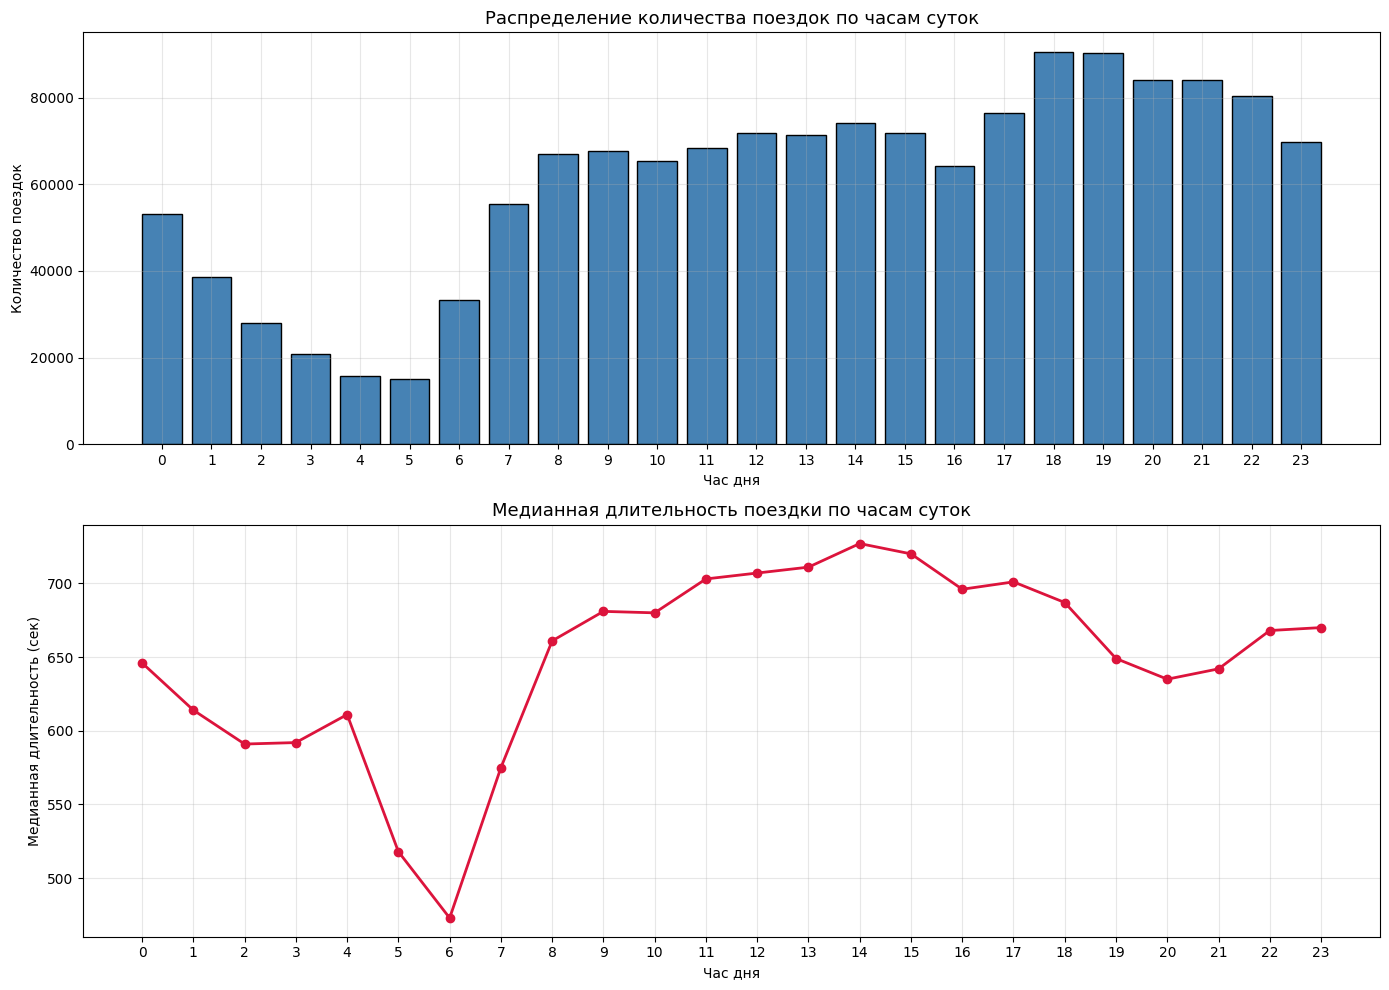

Количество поездок по часам:
pickup_hour
0     53234
1     38562
2     27966
3     20888
4     15784
5     14990
6     33233
7     55580
8     67040
9     67646
10    65420
11    68455
12    71858
13    71453
14    74265
15    71785
16    64285
17    76466
18    90581
19    90292
20    84049
21    84170
22    80469
23    69762
dtype: int64

Самое редкое время (мин. поездок):
  Час: 5:00
  Поездок: 14990

Самое популярное время (макс. поездок):
  Час: 18:00
  Поездок: 90581

Медианная длительность по часам:
pickup_hour
0     646.0
1     614.0
2     591.0
3     592.0
4     611.0
5     518.0
6     473.0
7     575.0
8     661.0
9     681.0
10    680.0
11    703.0
12    707.0
13    711.0
14    727.0
15    720.0
16    696.0
17    701.0
18    687.0
19    649.0
20    635.0
21    642.0
22    668.0
23    670.0
Name: trip_duration, dtype: float64

Час с максимальной медианной длительностью:
  Час: 14:00
  Медиана: 727 сек

Час с минимальной медианной длительностью:
  Час: 6:00
  Медиана: 473 сек


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Визуализации
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- График 1: количество поездок по часам ---
rides_by_hour = taxi_data.groupby('pickup_hour').size()

axes[0].bar(
    rides_by_hour.index,
    rides_by_hour.values,
    color='steelblue',
    edgecolor='black'
)
axes[0].set_title('Распределение количества поездок по часам суток', fontsize=13)
axes[0].set_xlabel('Час дня')
axes[0].set_ylabel('Количество поездок')
axes[0].set_xticks(range(0, 24))
axes[0].grid(alpha=0.3)

# --- График 2: медианная длительность поездок по часам ---
median_by_hour = taxi_data.groupby('pickup_hour')['trip_duration'].median()

axes[1].plot(
    median_by_hour.index,
    median_by_hour.values,
    marker='o',
    color='crimson',
    linewidth=2
)
axes[1].set_title('Медианная длительность поездки по часам суток', fontsize=13)
axes[1].set_xlabel('Час дня')
axes[1].set_ylabel('Медианная длительность (сек)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. Числовая проверка
# ============================================================
print("Количество поездок по часам:")
print(rides_by_hour)

print("\nСамое редкое время (мин. поездок):")
print(f"  Час: {rides_by_hour.idxmin()}:00")
print(f"  Поездок: {rides_by_hour.min()}")

print("\nСамое популярное время (макс. поездок):")
print(f"  Час: {rides_by_hour.idxmax()}:00")
print(f"  Поездок: {rides_by_hour.max()}")

print("\nМедианная длительность по часам:")
print(median_by_hour)

print("\nЧас с максимальной медианной длительностью:")
print(f"  Час: {median_by_hour.idxmax()}:00")
print(f"  Медиана: {median_by_hour.max():.0f} сек")

print("\nЧас с минимальной медианной длительностью:")
print(f"  Час: {median_by_hour.idxmin()}:00")
print(f"  Медиана: {median_by_hour.min():.0f} сек")

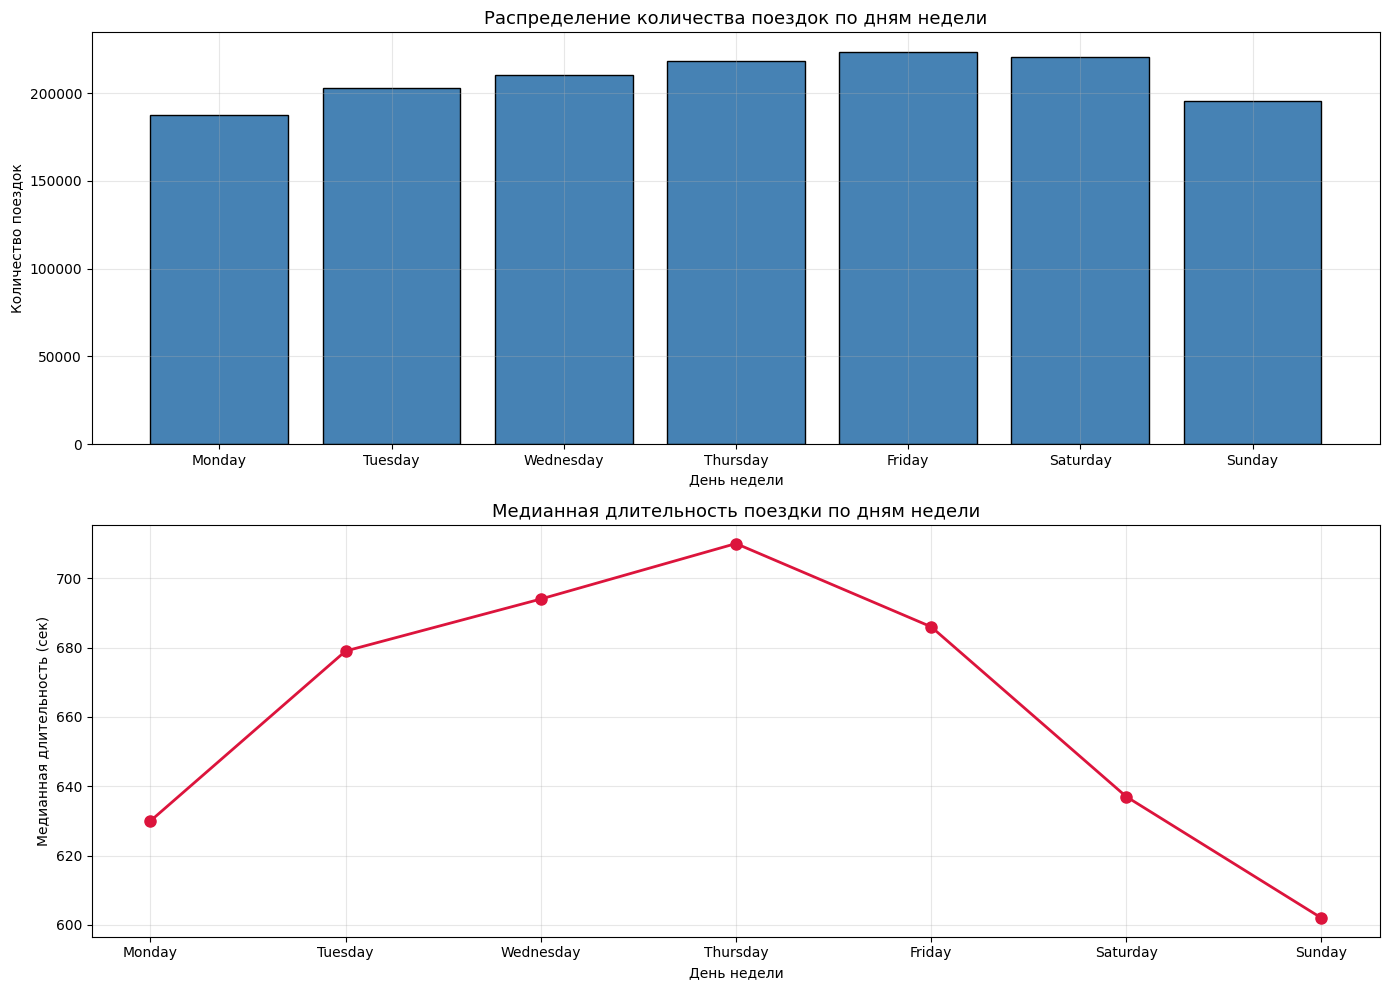

Количество поездок по дням недели:
  Monday    :  187,357
  Tuesday   :  202,696
  Wednesday :  210,094
  Thursday  :  218,497
  Friday    :  223,484
  Saturday  :  220,805
  Sunday    :  195,300

Больше всего поездок: Friday (223,484 поездок)

Медианная длительность по дням недели:
  Monday    :    630 сек
  Tuesday   :    679 сек
  Wednesday :    694 сек
  Thursday  :    710 сек
  Friday    :    686 сек
  Saturday  :    637 сек
  Sunday    :    602 сек

Наименьшая медианная длительность: Sunday (602 сек)
Наибольшая медианная длительность: Thursday (710 сек)


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Визуализации
# ============================================================
# Названия дней недели (0=Пн, 6=Вс)
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- График 1: количество поездок по дням недели ---
rides_by_day = taxi_data.groupby('pickup_day_of_week').size()

axes[0].bar(
    day_names,
    rides_by_day.values,
    color='steelblue',
    edgecolor='black'
)
axes[0].set_title('Распределение количества поездок по дням недели', fontsize=13)
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество поездок')
axes[0].grid(alpha=0.3)

# --- График 2: медианная длительность по дням недели ---
median_by_day = taxi_data.groupby('pickup_day_of_week')['trip_duration'].median()

axes[1].plot(
    day_names,
    median_by_day.values,
    marker='o',
    color='crimson',
    linewidth=2,
    markersize=8
)
axes[1].set_title('Медианная длительность поездки по дням недели', fontsize=13)
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Медианная длительность (сек)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. Числовая проверка
# ============================================================
print("Количество поездок по дням недели:")
for i, day in enumerate(day_names):
    print(f"  {day:10s}: {rides_by_day[i]:>8,}")

print(f"\nБольше всего поездок: {day_names[rides_by_day.idxmax()]} "
      f"({rides_by_day.max():,} поездок)")

print(f"\nМедианная длительность по дням недели:")
for i, day in enumerate(day_names):
    print(f"  {day:10s}: {median_by_day[i]:>6.0f} сек")

print(f"\nНаименьшая медианная длительность: {day_names[median_by_day.idxmin()]} "
      f"({median_by_day.min():.0f} сек)")
print(f"Наибольшая медианная длительность: {day_names[median_by_day.idxmax()]} "
      f"({median_by_day.max():.0f} сек)")

Сводная таблица (медианная длительность, сек):
             Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
pickup_hour                                                                
0             598.0    591.0      601.0     609.0   649.0     685.0   675.0
1             567.0    584.0      553.0     564.0   600.0     640.0   643.0
2             565.0    565.0      544.0     576.0   572.0     610.0   604.0
3             600.0    568.0      574.0     584.0   578.0     591.0   608.0
4             640.0    600.0      616.0     595.0   634.0     610.0   598.0
5             519.0    455.0      448.0     480.0   532.0     631.0   634.0
6             462.0    461.0      463.0     471.0   476.0     508.0   554.0
7             575.0    586.0      593.0     599.0   578.0     481.0   474.0
8             672.0    703.0      704.0     721.0   689.0     489.0   460.0
9             705.0    755.0      742.0     772.0   743.0     510.0   470.0
10            694.0    778.0      788.0  

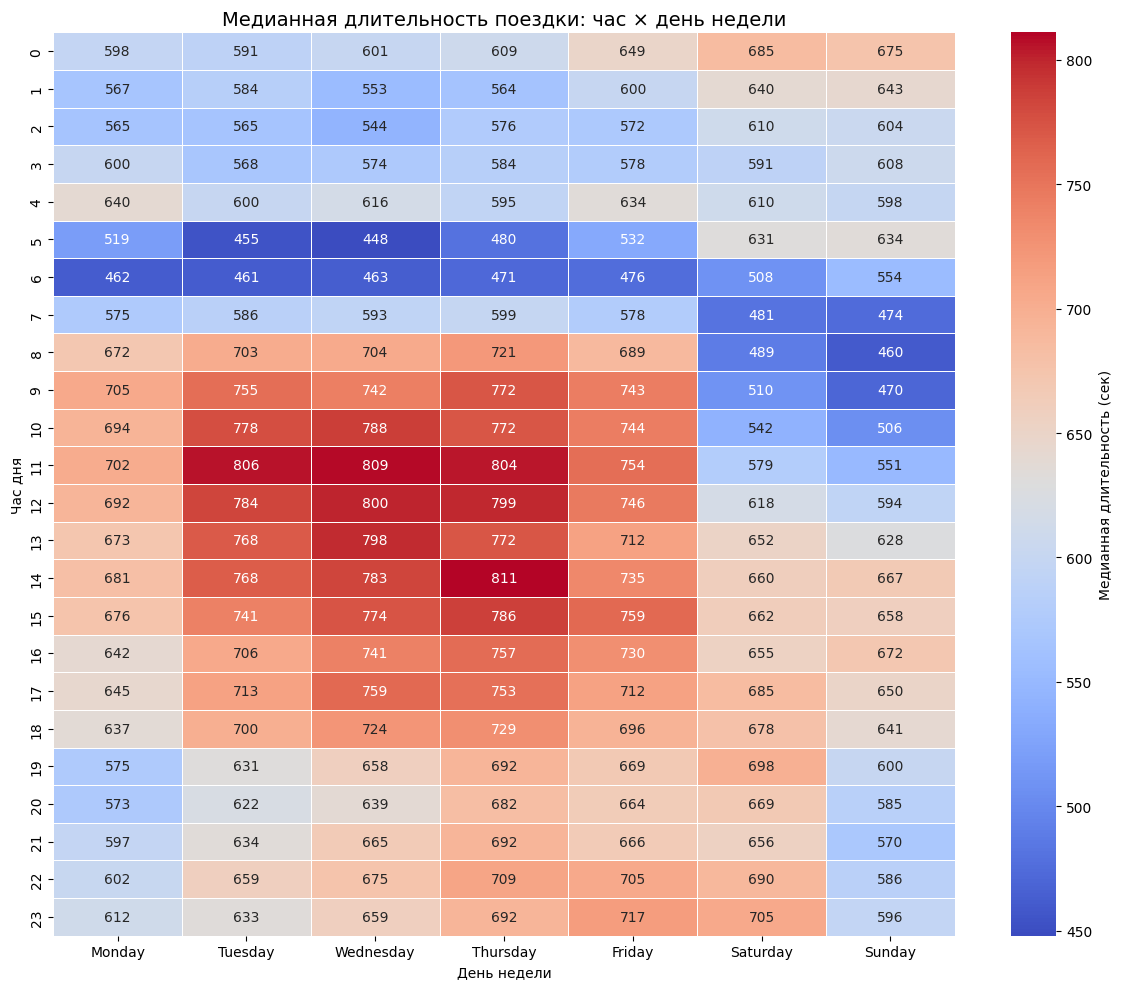


Максимальная медианная длительность: 811 сек
  Час: 14:00
  День: Thursday

=== Проверка вариантов ===
A. Максимум в будни 8–18: 811 сек
D. Максимум в будни 4–8:   721 сек
B. Четверг 14:00: 811 сек
C. Понедельник 17:00: 645 сек

Общий максимум: 811 сек (час 14, Thursday)


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Сводная таблица: часы × дни недели
# ============================================================
pivot = taxi_data.pivot_table(
    values='trip_duration',
    index='pickup_hour',
    columns='pickup_day_of_week',
    aggfunc='median'
)

# Переименуем столбцы для читаемости
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot.columns = day_names

print("Сводная таблица (медианная длительность, сек):")
print(pivot.round(0))


# ============================================================
# 2. Тепловая карта
# ============================================================
plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot,
    cmap='coolwarm',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Медианная длительность (сек)'}
)
plt.title('Медианная длительность поездки: час × день недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Час дня')
plt.tight_layout()
plt.show()


# ============================================================
# 3. Поиск максимума
# ============================================================
# Находим ячейку с максимальной медианой
max_val = pivot.max().max()
max_pos = np.unravel_index(pivot.values.argmax(), pivot.shape)
max_hour = pivot.index[max_pos[0]]
max_day = pivot.columns[max_pos[1]]

print(f"\nМаксимальная медианная длительность: {max_val:.0f} сек")
print(f"  Час: {max_hour}:00")
print(f"  День: {max_day}")


# ============================================================
# 4. Проверка вариантов ответа
# ============================================================
print("\n=== Проверка вариантов ===")

# A: будни 8-18
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
pivot_weekday_day = pivot.loc[8:18, weekdays]
print(f"A. Максимум в будни 8–18: {pivot_weekday_day.max().max():.0f} сек")

# D: будни 4-8
pivot_weekday_night = pivot.loc[4:8, weekdays]
print(f"D. Максимум в будни 4–8:   {pivot_weekday_night.max().max():.0f} сек")

# B: четверг 14:00
print(f"B. Четверг 14:00: {pivot.loc[14, 'Thursday']:.0f} сек")

# C: понедельник 17:00
print(f"C. Понедельник 17:00: {pivot.loc[17, 'Monday']:.0f} сек")

# Общий максимум
print(f"\nОбщий максимум: {max_val:.0f} сек (час {max_hour}, {max_day})")

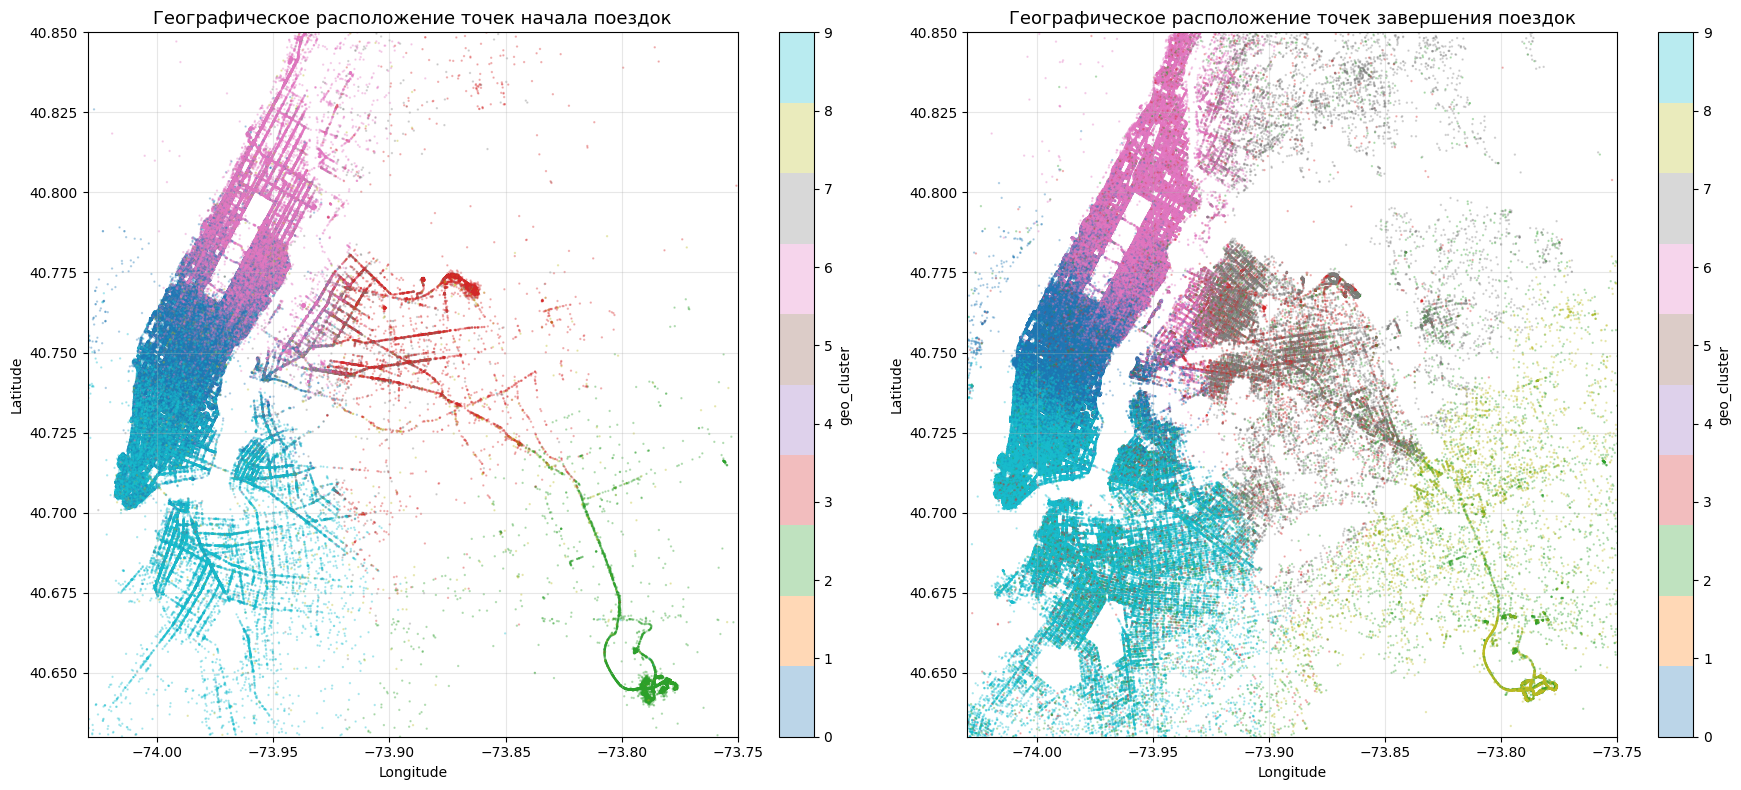

Всего кластеров: 10
Кластеров внутри NYC (pickup): [0, 2, 3, 6, 7, 8, 9]
Кластеров внутри NYC (dropoff): [0, 2, 3, 6, 7, 8, 9]
Кластеров внутри NYC (объединение): [0, 2, 3, 6, 7, 8, 9]

Кластеров ЗА границами NYC: [1, 4, 5]
Их количество: 3


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Границы Нью-Йорка
# ============================================================
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)


# ============================================================
# 2. Фильтруем данные по границам NYC
# ============================================================
mask_pickup = (
    (taxi_data['pickup_longitude'].between(*city_long_border)) &
    (taxi_data['pickup_latitude'].between(*city_lat_border))
)

mask_dropoff = (
    (taxi_data['dropoff_longitude'].between(*city_long_border)) &
    (taxi_data['dropoff_latitude'].between(*city_lat_border))
)


# ============================================================
# 3. Строим два scatter-графика
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- График 1: точки начала поездок ---
scatter1 = axes[0].scatter(
    taxi_data.loc[mask_pickup, 'pickup_longitude'],
    taxi_data.loc[mask_pickup, 'pickup_latitude'],
    c=taxi_data.loc[mask_pickup, 'geo_cluster'],
    cmap='tab10',
    s=0.5,          # маленький размер точек
    alpha=0.3
)
axes[0].set_title('Географическое расположение точек начала поездок', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(city_long_border)
axes[0].set_ylim(city_lat_border)
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='geo_cluster')

# --- График 2: точки завершения поездок ---
scatter2 = axes[1].scatter(
    taxi_data.loc[mask_dropoff, 'dropoff_longitude'],
    taxi_data.loc[mask_dropoff, 'dropoff_latitude'],
    c=taxi_data.loc[mask_dropoff, 'geo_cluster'],
    cmap='tab10',
    s=0.5,
    alpha=0.3
)
axes[1].set_title('Географическое расположение точек завершения поездок', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_xlim(city_long_border)
axes[1].set_ylim(city_lat_border)
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='geo_cluster')

plt.tight_layout()
plt.show()


# ============================================================
# 4. Сколько кластеров не попало в границы NYC?
# ============================================================

# Все кластеры, которые есть в данных
all_clusters = set(taxi_data['geo_cluster'].unique())

# Кластеры, которые встречаются в точках pickup внутри границ
clusters_in_pickup = set(taxi_data.loc[mask_pickup, 'geo_cluster'].unique())

# Кластеры, которые встречаются в точках dropoff внутри границ
clusters_in_dropoff = set(taxi_data.loc[mask_dropoff, 'geo_cluster'].unique())

# Кластеры, которые есть в pickup ИЛИ в dropoff внутри границ
clusters_in_nyc = clusters_in_pickup | clusters_in_dropoff

# Кластеры, которых НЕТ в границах
clusters_outside = all_clusters - clusters_in_nyc

print(f"Всего кластеров: {len(all_clusters)}")
print(f"Кластеров внутри NYC (pickup): {sorted(clusters_in_pickup)}")
print(f"Кластеров внутри NYC (dropoff): {sorted(clusters_in_dropoff)}")
print(f"Кластеров внутри NYC (объединение): {sorted(clusters_in_nyc)}")
print(f"\nКластеров ЗА границами NYC: {sorted(clusters_outside)}")
print(f"Их количество: {len(clusters_outside)}")

In [41]:
print('Shape of data: {}'.format(taxi_data.shape))
print('Columns: {}'.format(taxi_data.columns))

Shape of data: (1458233, 28)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind_speed', 'precip', 'events',
       'avg_speed', 'trip_duration_log'],
      dtype='object')


In [42]:
train_data = taxi_data.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,haversine_distance,direction,geo_cluster,temperature,visibility,wind_speed,precip,events,avg_speed,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,1.498521,99.970196,6,4.4,8.0,27.8,0.3,None,15.896176,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,1.805507,-117.153768,9,28.9,16.1,7.4,0.0,None,13.646335,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,6.385098,-159.680165,9,-6.7,16.1,24.1,0.0,None,18.747119,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,1.485498,-172.737700,9,7.2,16.1,25.9,0.0,None,14.932028,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,1.188588,179.473585,6,9.4,16.1,9.3,0.0,None,13.364690,6.077642


In [45]:
# Удаляем:
# - avg_speed (утечка + использовался только для фильтрации)
# - id (уникальный, бесполезный)
# - dropoff_datetime (утечка целевой переменной)

train_data = train_data.drop(['avg_speed'], axis=1)

print(f"Размер: {train_data.shape}")
print(f"Столбцов: {train_data.shape[1]}")

Размер: (1458233, 25)
Столбцов: 25


In [46]:
drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


In [47]:
# ============================================================
# Кодируем vendor_id: 1 → 0, 2 → 1
# ============================================================
train_data['vendor_id'] = train_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)

# Проверка
print("vendor_id — уникальные значения после кодирования:")
print(train_data['vendor_id'].value_counts())
print(f"Среднее по vendor_id: {train_data['vendor_id'].mean():.2f}")


# ============================================================
# Кодируем store_and_fwd_flag: 'N' → 0, 'Y' → 1
# ============================================================
train_data['store_and_fwd_flag'] = train_data['store_and_fwd_flag'].apply(
    lambda x: 0 if x == 'N' else 1
)

# Проверка
print("\nstore_and_fwd_flag — уникальные значения после кодирования:")
print(train_data['store_and_fwd_flag'].value_counts())
print(f"Среднее по store_and_fwd_flag: {train_data['store_and_fwd_flag'].mean():.3f}")

vendor_id — уникальные значения после кодирования:
1    780118
0    678115
Name: vendor_id, dtype: int64
Среднее по vendor_id: 0.53

store_and_fwd_flag — уникальные значения после кодирования:
0    1450192
1       8041
Name: store_and_fwd_flag, dtype: int64
Среднее по store_and_fwd_flag: 0.006


In [49]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 1. Объявляем кодировщик
#    sparse_output=False — чтобы получить плотный numpy-массив
# ============================================================
one_hot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)


# ============================================================
# 2. Список категориальных столбцов для кодирования
# ============================================================
categorical_cols = ['pickup_day_of_week', 'geo_cluster', 'events']


# ============================================================
# 3. Обучаем и трансформируем
# ============================================================
data_onehot = one_hot_encoder.fit_transform(train_data[categorical_cols])
print(f"Тип результата: {type(data_onehot)}")
print(f"Форма numpy-массива: {data_onehot.shape}")


# ============================================================
# 4. Получаем имена новых столбцов
# ============================================================
column_names = one_hot_encoder.get_feature_names_out(categorical_cols)
print(f"\nИмена закодированных столбцов ({len(column_names)} шт.):")
for name in column_names:
    print(f"  - {name}")


# ============================================================
# 5. Создаём DataFrame
# ============================================================
data_onehot = pd.DataFrame(data_onehot, columns=column_names)

print(f"\nФорма data_onehot: {data_onehot.shape}")
print("\nПервые 5 строк:")
print(data_onehot.head())


# ============================================================
# 6. Ответ на вопрос: сколько бинарных столбцов получилось?
# ============================================================
n_columns = data_onehot.shape[1]
print(f"\n{'=' * 50}")
print(f"Количество бинарных столбцов: {n_columns}")
print(f"{'=' * 50}")

Тип результата: <class 'numpy.ndarray'>
Форма numpy-массива: (1458233, 18)

Имена закодированных столбцов (18 шт.):
  - pickup_day_of_week_1
  - pickup_day_of_week_2
  - pickup_day_of_week_3
  - pickup_day_of_week_4
  - pickup_day_of_week_5
  - pickup_day_of_week_6
  - geo_cluster_1
  - geo_cluster_2
  - geo_cluster_3
  - geo_cluster_4
  - geo_cluster_5
  - geo_cluster_6
  - geo_cluster_7
  - geo_cluster_8
  - geo_cluster_9
  - events_None
  - events_Rain
  - events_Snow

Форма data_onehot: (1458233, 18)

Первые 5 строк:
   pickup_day_of_week_1  pickup_day_of_week_2  pickup_day_of_week_3  \
0                   0.0                   0.0                   0.0   
1                   0.0                   0.0                   0.0   
2                   1.0                   0.0                   0.0   
3                   0.0                   1.0                   0.0   
4                   0.0                   0.0                   0.0   

   pickup_day_of_week_4  pickup_day_of_week_5 

In [54]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import feature_selection
from sklearn import model_selection


# ============================================================
# 1. OneHotEncoder для категориальных признаков
# ============================================================
one_hot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

categorical_cols = ['pickup_day_of_week', 'geo_cluster', 'events']

# Проверяем, что эти столбцы ещё есть в train_data
categorical_cols = [c for c in categorical_cols if c in train_data.columns]
print(f"Кодируем столбцы: {categorical_cols}")

data_onehot = one_hot_encoder.fit_transform(train_data[categorical_cols])
column_names = one_hot_encoder.get_feature_names_out(categorical_cols)
data_onehot = pd.DataFrame(data_onehot, columns=column_names)

print(f"data_onehot: {data_onehot.shape}")


# ============================================================
# 2. Присоединяем data_onehot к train_data
# ============================================================
train_data = pd.concat([train_data.reset_index(drop=True), data_onehot], axis=1)

# Удаляем исходные категориальные столбцы
train_data = train_data.drop(categorical_cols, axis=1)

print(f"train_data после concat: {train_data.shape}")


# ============================================================
# 3. Проверка: все ли столбцы числовые?
# ============================================================
non_numeric = train_data.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f"⚠️ Нечисловые столбцы: {non_numeric}")
    # Удаляем их, если остались
    train_data = train_data.drop(non_numeric, axis=1)
    print(f"Удалены. Новая форма: {train_data.shape}")
else:
    print("✅ Все столбцы числовые")


# ============================================================
# 4. Формируем X, y, y_log
# ============================================================
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

print(f"\nРазмер X: {X.shape}")


# ============================================================
# 5. Разделяем на train/valid
# ============================================================
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log,
    test_size=0.33,
    random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Valid: {X_valid.shape}")


# ============================================================
# 6. Отбор 25 лучших признаков
# ============================================================
selector = feature_selection.SelectKBest(
    score_func=feature_selection.f_regression,
    k=25
)

X_train_selected = selector.fit_transform(X_train, y_train_log)
X_valid_selected = selector.transform(X_valid)

selected_features = X_train.columns[selector.get_support()]
print(f"\nОтобрано признаков: {len(selected_features)}")
print("\nСписок отобранных признаков:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")


# ============================================================
# 7. Оставляем только отобранные признаки
# ============================================================
X_train = X_train[selected_features]
X_valid = X_valid[selected_features]

print(f"\nФорма X_train: {X_train.shape}")
print(f"Форма X_valid: {X_valid.shape}")


# ============================================================
# 8. Проверка признаков A-G
# ============================================================
check_features = ['vendor_id', 'passenger_count', 'number_of_steps',
                  'temperature', 'events_None', 'visibility', 'wind_speed']

print("\n" + "=" * 50)
print("Проверка признаков A-G:")
print("=" * 50)
for feat in check_features:
    mark = "✅ В топ-25" if feat in selected_features.tolist() else "❌ НЕ в топ-25"
    print(f"  {feat:20s}: {mark}")

Кодируем столбцы: []
data_onehot: (1458233, 0)
train_data после concat: (1458233, 20)
✅ Все столбцы числовые

Размер X: (1458233, 18)
Train: (977016, 18)
Valid: (481217, 18)


C:\Users\nikon\AppData\Roaming\Python\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=25 is greater than n_features=18. All the features will be returned.
  warnings.warn(



Отобрано признаков: 18

Список отобранных признаков:
   1. vendor_id
   2. passenger_count
   3. pickup_longitude
   4. pickup_latitude
   5. dropoff_longitude
   6. dropoff_latitude
   7. store_and_fwd_flag
   8. pickup_hour
   9. pickup_holiday
  10. total_distance
  11. total_travel_time
  12. number_of_steps
  13. haversine_distance
  14. direction
  15. temperature
  16. visibility
  17. wind_speed
  18. precip

Форма X_train: (977016, 18)
Форма X_valid: (481217, 18)

Проверка признаков A-G:
  vendor_id           : ✅ В топ-25
  passenger_count     : ✅ В топ-25
  number_of_steps     : ✅ В топ-25
  temperature         : ✅ В топ-25
  events_None         : ❌ НЕ в топ-25
  visibility          : ✅ В топ-25
  wind_speed          : ✅ В топ-25


In [55]:
print(data_onehot.shape)
print(data_onehot.columns.tolist()[:5])

(1458233, 0)
[]


In [56]:
# Что сейчас в train_data
print("train_data columns:", train_data.columns.tolist())
print("train_data shape:", train_data.shape)

# Есть ли категориальные столбцы в taxi_data?
print("\nВ taxi_data есть:")
for col in ['pickup_day_of_week', 'geo_cluster', 'events']:
    print(f"  {col}: {'✅' if col in taxi_data.columns else '❌'}")

train_data columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_hour', 'pickup_holiday', 'total_distance', 'total_travel_time', 'number_of_steps', 'haversine_distance', 'direction', 'temperature', 'visibility', 'wind_speed', 'precip', 'trip_duration_log']
train_data shape: (1458233, 20)

В taxi_data есть:
  pickup_day_of_week: ✅
  geo_cluster: ✅
  events: ✅


In [57]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import feature_selection
from sklearn import model_selection


# ============================================================
# 1. Восстанавливаем категориальные столбцы из taxi_data
# ============================================================
cat_cols = ['pickup_day_of_week', 'geo_cluster', 'events']

for col in cat_cols:
    train_data[col] = taxi_data[col].values

print(f"train_data после восстановления: {train_data.shape}")
print(f"Восстановлены: {cat_cols}")


# ============================================================
# 2. OneHotEncoder
# ============================================================
one_hot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

data_onehot = one_hot_encoder.fit_transform(train_data[cat_cols])
column_names = one_hot_encoder.get_feature_names_out(cat_cols)
data_onehot = pd.DataFrame(data_onehot, columns=column_names)

print(f"\ndata_onehot: {data_onehot.shape}")
print("Имена столбцов:", column_names.tolist())


# ============================================================
# 3. Присоединяем data_onehot к train_data и удаляем исходные
# ============================================================
train_data = pd.concat(
    [train_data.reset_index(drop=True), data_onehot],
    axis=1
)
train_data = train_data.drop(cat_cols, axis=1)

print(f"\ntrain_data после concat: {train_data.shape}")


# ============================================================
# 4. Проверка: все ли столбцы числовые?
# ============================================================
non_numeric = train_data.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f"⚠️ Нечисловые: {non_numeric}")
    train_data = train_data.drop(non_numeric, axis=1)
    print(f"После удаления: {train_data.shape}")
else:
    print("✅ Все столбцы числовые")


# ============================================================
# 5. Формируем X, y, y_log
# ============================================================
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

print(f"\nРазмер X: {X.shape}")   # ожидаем ~38


# ============================================================
# 6. Train/valid split
# ============================================================
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log,
    test_size=0.33,
    random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Valid: {X_valid.shape}")


# ============================================================
# 7. SelectKBest — отбор 25 признаков
# ============================================================
selector = feature_selection.SelectKBest(
    score_func=feature_selection.f_regression,
    k=25
)

X_train_selected = selector.fit_transform(X_train, y_train_log)
X_valid_selected = selector.transform(X_valid)

selected_features = X_train.columns[selector.get_support()]
print(f"\n{'=' * 50}")
print(f"Отобрано признаков: {len(selected_features)}")
print(f"{'=' * 50}")
print("\nСписок отобранных признаков:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")


# ============================================================
# 8. Оставляем только отобранные признаки
# ============================================================
X_train = X_train[selected_features]
X_valid = X_valid[selected_features]

print(f"\nФорма X_train: {X_train.shape}")
print(f"Форма X_valid: {X_valid.shape}")


# ============================================================
# 9. Проверка признаков A-G из задания 4.4
# ============================================================
check_features = {
    'A': 'vendor_id',
    'B': 'passenger_count',
    'C': 'number_of_steps',
    'D': 'temperature',
    'E': 'events_None',
    'F': 'visibility',
    'G': 'wind_speed'
}

print("\n" + "=" * 50)
print("Проверка признаков A-G из задания 4.4:")
print("=" * 50)
for letter, feat in check_features.items():
    mark = "✅ В топ-25" if feat in selected_features.tolist() else "❌ НЕ в топ-25"
    print(f"  {letter}. {feat:20s}: {mark}")

train_data после восстановления: (1458233, 23)
Восстановлены: ['pickup_day_of_week', 'geo_cluster', 'events']

data_onehot: (1458233, 18)
Имена столбцов: ['pickup_day_of_week_1', 'pickup_day_of_week_2', 'pickup_day_of_week_3', 'pickup_day_of_week_4', 'pickup_day_of_week_5', 'pickup_day_of_week_6', 'geo_cluster_1', 'geo_cluster_2', 'geo_cluster_3', 'geo_cluster_4', 'geo_cluster_5', 'geo_cluster_6', 'geo_cluster_7', 'geo_cluster_8', 'geo_cluster_9', 'events_None', 'events_Rain', 'events_Snow']

train_data после concat: (1458233, 38)
✅ Все столбцы числовые

Размер X: (1458233, 36)
Train: (977016, 36)
Valid: (481217, 36)

Отобрано признаков: 25

Список отобранных признаков:
   1. vendor_id
   2. passenger_count
   3. pickup_longitude
   4. pickup_latitude
   5. dropoff_longitude
   6. dropoff_latitude
   7. store_and_fwd_flag
   8. pickup_hour
   9. pickup_holiday
  10. total_distance
  11. total_travel_time
  12. number_of_steps
  13. haversine_distance
  14. temperature
  15. pickup_day_

In [58]:
from sklearn.preprocessing import MinMaxScaler


# ============================================================
# 1. Создаём и обучаем MinMaxScaler на тренировочной выборке
# ============================================================
scaler = MinMaxScaler()

# fit + transform на train
X_train_scaled = scaler.fit_transform(X_train)

# только transform на valid (используем статистики из train!)
X_valid_scaled = scaler.transform(X_valid)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_valid_scaled shape: {X_valid_scaled.shape}")


# ============================================================
# 2. Преобразуем обратно в DataFrame (для удобства)
# ============================================================
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)


# ============================================================
# 3. Проверка: min и max в train должны быть 0 и 1
# ============================================================
print("\nПроверка X_train_scaled (min, max):")
print(f"  min: {X_train_scaled.min().min():.4f}")
print(f"  max: {X_train_scaled.max().max():.4f}")

print("\nПроверка X_valid_scaled (min, max):")
print(f"  min: {X_valid_scaled.min().min():.4f}")
print(f"  max: {X_valid_scaled.max().max():.4f}")
# min/max на valid могут выходить за [0, 1] — это нормально


# ============================================================
# 4. Среднее первого предиктора в валидационной выборке
# ============================================================
first_predictor = X_valid_scaled.columns[0]
mean_first = X_valid_scaled.iloc[:, 0].mean()

print(f"\nПервый предиктор: {first_predictor}")
print(f"Среднее первого предиктора (valid): {mean_first:.2f}")

X_train_scaled shape: (977016, 25)
X_valid_scaled shape: (481217, 25)

Проверка X_train_scaled (min, max):
  min: 0.0000
  max: 1.0000

Проверка X_valid_scaled (min, max):
  min: -0.0000
  max: 1.2857

Первый предиктор: vendor_id
Среднее первого предиктора (valid): 0.54


In [60]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Обучаем линейную регрессию
# ============================================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)

print("Модель обучена")
print(f"  Свободный член: {lr.intercept_:.4f}")
print(f"  Коэффициентов: {len(lr.coef_)}")


# ============================================================
# 2. Предсказания
# ============================================================
y_train_pred = lr.predict(X_train_scaled)
y_valid_pred = lr.predict(X_valid_scaled)


# ============================================================
# 3. RMSLE (для логарифмированного таргета = RMSE)
# ============================================================
rmsle_train = np.sqrt(mean_squared_error(y_train_log, y_train_pred))
rmsle_valid = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred))

print(f"\nRMSLE на тренировочной выборке: {rmsle_train:.2f}")
print(f"RMSLE на валидационной выборке:  {rmsle_valid:.2f}")

Модель обучена
  Свободный член: -10.1173
  Коэффициентов: 25

RMSLE на тренировочной выборке: 0.54
RMSLE на валидационной выборке:  0.54


In [61]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Генерируем полиномиальные признаки 2-й степени
# ============================================================
poly = PolynomialFeatures(degree=2, include_bias=False)

# fit_transform на train, transform на valid
X_train_poly = poly.fit_transform(X_train_scaled)
X_valid_poly = poly.transform(X_valid_scaled)

print(f"X_train_poly shape: {X_train_poly.shape}")
print(f"X_valid_poly shape: {X_valid_poly.shape}")
print(f"Было признаков: {X_train_scaled.shape[1]}")
print(f"Стало признаков: {X_train_poly.shape[1]}")


# ============================================================
# 2. Обучаем линейную регрессию на полиномиальных признаках
# ============================================================
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_log)


# ============================================================
# 3. Предсказания
# ============================================================
y_train_pred_poly = lr_poly.predict(X_train_poly)
y_valid_pred_poly = lr_poly.predict(X_valid_poly)


# ============================================================
# 4. RMSLE (для логарифмированного таргета = RMSE)
# ============================================================
rmsle_train_poly = np.sqrt(mean_squared_error(y_train_log, y_train_pred_poly))
rmsle_valid_poly = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_poly))

print(f"\nRMSLE на тренировочной выборке: {rmsle_train_poly:.2f}")
print(f"RMSLE на валидационной выборке:  {rmsle_valid_poly:.2f}")
print(f"Разница (train − valid):        {rmsle_train_poly - rmsle_valid_poly:.2f}")

X_train_poly shape: (977016, 350)
X_valid_poly shape: (481217, 350)
Было признаков: 25
Стало признаков: 350

RMSLE на тренировочной выборке: 0.47
RMSLE на валидационной выборке:  0.51
Разница (train − valid):        -0.04


In [62]:
print(f"RMSLE train (poly): {rmsle_train_poly:.4f}")
print(f"RMSLE valid (poly): {rmsle_valid_poly:.4f}")

# Проверка формы
print(f"\nX_train shape: {X_train_scaled.shape}")
print(f"X_valid shape: {X_valid_scaled.shape}")

# Проверка порядка строк
print(f"\ny_train_log первые 3 значения: {y_train_log.head(3).values}")
print(f"y_valid_log первые 3 значения: {y_valid_log.head(3).values}")

# Проверка, что полиномы обучены ТОЛЬКО на train
print(f"\nБыло признаков: {X_train_scaled.shape[1]}")
print(f"Стало: {X_train_poly.shape[1]} (train)")
print(f"Стало: {X_valid_poly.shape[1]} (valid)")

RMSLE train (poly): 0.4669
RMSLE valid (poly): 0.5053

X_train shape: (977016, 25)
X_valid shape: (481217, 25)

y_train_log первые 3 значения: [6.2441669  6.03308622 5.56068163]
y_valid_log первые 3 значения: [5.96614674 5.22035583 2.19722458]

Было признаков: 25
Стало: 350 (train)
Стало: 350 (valid)


In [63]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Обучаем Ridge-регрессию на полиномиальных признаках
#    alpha=1 — коэффициент регуляризации
# ============================================================
ridge = Ridge(alpha=1)
ridge.fit(X_train_poly, y_train_log)

print("Модель Ridge обучена")
print(f"  alpha: {ridge.alpha}")
print(f"  Свободный член: {ridge.intercept_:.4f}")


# ============================================================
# 2. Предсказания
# ============================================================
y_train_pred_ridge = ridge.predict(X_train_poly)
y_valid_pred_ridge = ridge.predict(X_valid_poly)


# ============================================================
# 3. RMSLE = RMSE для логарифмированного таргета
# ============================================================
rmsle_train_ridge = np.sqrt(mean_squared_error(y_train_log, y_train_pred_ridge))
rmsle_valid_ridge = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_ridge))

print(f"\nRMSLE на тренировочной выборке: {rmsle_train_ridge:.2f}")
print(f"RMSLE на валидационной выборке:  {rmsle_valid_ridge:.2f}")
print(f"Разница (valid − train):         {rmsle_valid_ridge - rmsle_train_ridge:.2f}")

Модель Ridge обучена
  alpha: 1
  Свободный член: -4.7561

RMSLE на тренировочной выборке: 0.48
RMSLE на валидационной выборке:  0.48
Разница (valid − train):         0.00


In [64]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Обучаем дерево решений
#    ВАЖНО: используем X_train_scaled (25 признаков),
#    а не полиномиальные — дерево само найдёт нелинейности
# ============================================================
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train_log)

print("Дерево решений обучено")
print(f"  Глубина: {dt.get_depth()}")
print(f"  Число листьев: {dt.get_n_leaves()}")


# ============================================================
# 2. Предсказания
# ============================================================
y_train_pred_dt = dt.predict(X_train_scaled)
y_valid_pred_dt = dt.predict(X_valid_scaled)


# ============================================================
# 3. RMSLE = RMSE для логарифмированного таргета
# ============================================================
rmsle_train_dt = np.sqrt(mean_squared_error(y_train_log, y_train_pred_dt))
rmsle_valid_dt = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_dt))

print(f"\nRMSLE на тренировочной выборке: {rmsle_train_dt:.2f}")
print(f"RMSLE на валидационной выборке:  {rmsle_valid_dt:.2f}")
print(f"\n4 знака после запятой:")
print(f"  train: {rmsle_train_dt:.4f}")
print(f"  valid: {rmsle_valid_dt:.4f}")
print(f"  разница: {rmsle_valid_dt - rmsle_train_dt:.4f}")

Дерево решений обучено
  Глубина: 61
  Число листьев: 970593

RMSLE на тренировочной выборке: 0.00
RMSLE на валидационной выборке:  0.57

4 знака после запятой:
  train: 0.0030
  valid: 0.5655
  разница: 0.5625


depth= 7 | train=0.4448 | valid=0.4471
depth= 8 | train=0.4370 | valid=0.4408
depth= 9 | train=0.4299 | valid=0.4356
depth=10 | train=0.4224 | valid=0.4313
depth=11 | train=0.4146 | valid=0.4297
depth=12 | train=0.4059 | valid=0.4301
depth=13 | train=0.3956 | valid=0.4324
depth=14 | train=0.3838 | valid=0.4372
depth=15 | train=0.3704 | valid=0.4444
depth=16 | train=0.3557 | valid=0.4530
depth=17 | train=0.3395 | valid=0.4607
depth=18 | train=0.3221 | valid=0.4720
depth=19 | train=0.3034 | valid=0.4822

     max_depth  rmsle_train  rmsle_valid
0           7     0.444832     0.447149
1           8     0.437023     0.440755
2           9     0.429945     0.435635
3          10     0.422442     0.431279
4          11     0.414560     0.429676
5          12     0.405881     0.430119
6          13     0.395605     0.432371
7          14     0.383772     0.437176
8          15     0.370353     0.444431
9          16     0.355725     0.452963
10         17     0.339457     0.460704
11         

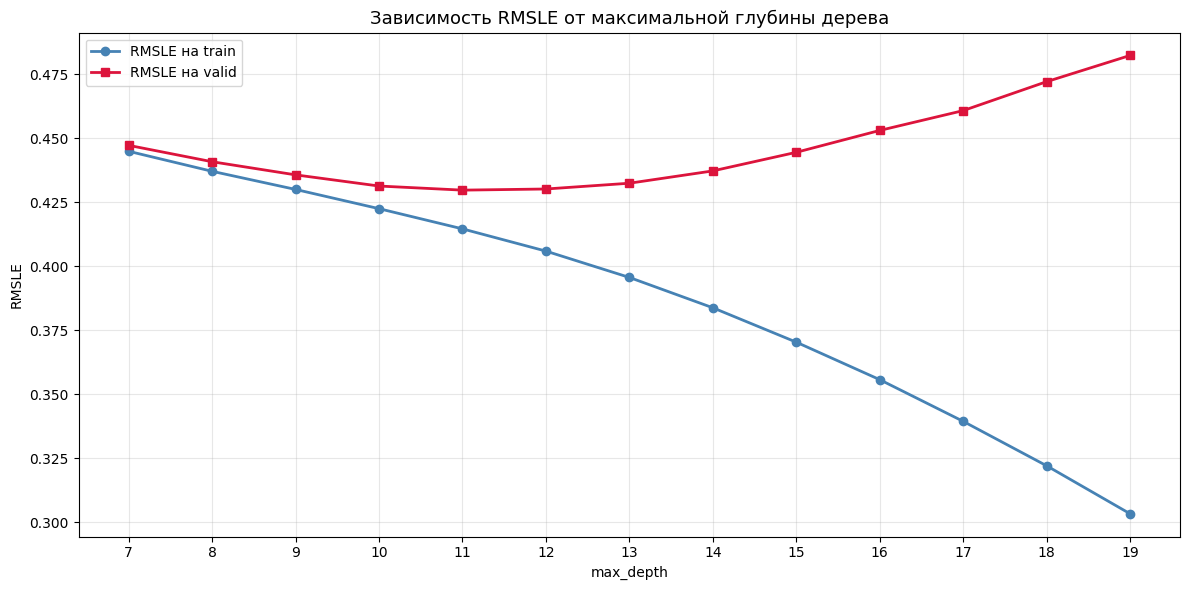


Оптимальная глубина: 11
  RMSLE train: 0.41
  RMSLE valid: 0.43


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Перебираем глубины от 7 до 19
# ============================================================
max_depths = range(7, 20)

results = []

for depth in max_depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train_log)
    
    y_train_pred = dt.predict(X_train_scaled)
    y_valid_pred = dt.predict(X_valid_scaled)
    
    rmsle_train = np.sqrt(mean_squared_error(y_train_log, y_train_pred))
    rmsle_valid = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred))
    
    results.append({
        'max_depth': depth,
        'rmsle_train': rmsle_train,
        'rmsle_valid': rmsle_valid
    })
    print(f"depth={depth:2d} | train={rmsle_train:.4f} | valid={rmsle_valid:.4f}")

results_df = pd.DataFrame(results)
print("\n", results_df)


# ============================================================
# 2. Строим линейные графики
# ============================================================
plt.figure(figsize=(12, 6))

plt.plot(results_df['max_depth'], results_df['rmsle_train'],
         marker='o', label='RMSLE на train', color='steelblue', linewidth=2)
plt.plot(results_df['max_depth'], results_df['rmsle_valid'],
         marker='s', label='RMSLE на valid', color='crimson', linewidth=2)

plt.title('Зависимость RMSLE от максимальной глубины дерева', fontsize=13)
plt.xlabel('max_depth')
plt.ylabel('RMSLE')
plt.xticks(max_depths)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3. Находим оптимальную глубину
# ============================================================
# Оптимум — min RMSLE на valid, при этом train ещё не ушёл в 0
optimal_idx = results_df['rmsle_valid'].idxmin()
optimal_depth = results_df.loc[optimal_idx, 'max_depth']
optimal_train = results_df.loc[optimal_idx, 'rmsle_train']
optimal_valid = results_df.loc[optimal_idx, 'rmsle_valid']

print(f"\n{'=' * 50}")
print(f"Оптимальная глубина: {optimal_depth}")
print(f"  RMSLE train: {optimal_train:.2f}")
print(f"  RMSLE valid: {optimal_valid:.2f}")
print(f"{'=' * 50}")

In [66]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Обучаем RandomForestRegressor
#    ⚠️ Это может занять 10–30 минут на 1.5 млн строк!
#    verbose=True покажет прогресс
# ============================================================
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    criterion='squared_error',
    min_samples_split=20,
    random_state=42,
    n_jobs=-1,        # используем все ядра CPU
    verbose=1         # показываем прогресс
)

rf.fit(X_train_scaled, y_train_log)
print("Модель обучена!")


# ============================================================
# 2. Предсказания
# ============================================================
y_train_pred_rf = rf.predict(X_train_scaled)
y_valid_pred_rf = rf.predict(X_valid_scaled)


# ============================================================
# 3. RMSLE = RMSE для логарифмированного таргета
# ============================================================
rmsle_train_rf = np.sqrt(mean_squared_error(y_train_log, y_train_pred_rf))
rmsle_valid_rf = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_rf))

print(f"\n{'=' * 50}")
print(f"RMSLE на тренировочной выборке: {rmsle_train_rf:.2f}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_rf:.2f}")
print(f"{'=' * 50}")
print(f"\n4 знака после запятой:")
print(f"  train: {rmsle_train_rf:.4f}")
print(f"  valid: {rmsle_valid_rf:.4f}")
print(f"  разница: {rmsle_valid_rf - rmsle_train_rf:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   18.7s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.9min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.


Модель обучена!


[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    2.6s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    3.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    1.2s



RMSLE на тренировочной выборке: 0.40
RMSLE на валидационной выборке: 0.41

4 знака после запятой:
  train: 0.3992
  valid: 0.4140
  разница: 0.0149


[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    1.4s finished


In [67]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Обучаем GradientBoostingRegressor
#    ⚠️ Обучение последовательное → может занять 5–15 минут
# ============================================================
gb = GradientBoostingRegressor(
    learning_rate=0.5,
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    random_state=42,
    verbose=1   # показываем прогресс
)

gb.fit(X_train_scaled, y_train_log)
print("\nМодель обучена!")


# ============================================================
# 2. Предсказания
# ============================================================
y_train_pred_gb = gb.predict(X_train_scaled)
y_valid_pred_gb = gb.predict(X_valid_scaled)


# ============================================================
# 3. RMSLE = RMSE для логарифмированного таргета
# ============================================================
rmsle_train_gb = np.sqrt(mean_squared_error(y_train_log, y_train_pred_gb))
rmsle_valid_gb = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_gb))

print(f"\n{'=' * 50}")
print(f"RMSLE на тренировочной выборке: {rmsle_train_gb:.2f}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_gb:.2f}")
print(f"{'=' * 50}")
print(f"\n4 знака после запятой:")
print(f"  train: {rmsle_train_gb:.4f}")
print(f"  valid: {rmsle_valid_gb:.4f}")
print(f"  разница: {rmsle_valid_gb - rmsle_train_gb:.4f}")

      Iter       Train Loss   Remaining Time 
         1           0.3110           11.92m
         2           0.2247           11.97m
         3           0.1987           12.08m
         4           0.1876           12.05m
         5           0.1823           12.02m
         6           0.1784           11.90m
         7           0.1752           11.80m
         8           0.1725           11.74m
         9           0.1713           11.66m
        10           0.1688           11.60m
        20           0.1599           10.56m
        30           0.1538            9.46m
        40           0.1505            8.38m
        50           0.1479            7.24m
        60           0.1453            7.80m
        70           0.1430            5.50m
        80           0.1415            3.50m
        90           0.1402            1.69m
       100           0.1382            0.00s

Модель обучена!

RMSLE на тренировочной выборке: 0.37
RMSLE на валидационной выборке: 0.39

4 знак

Важность признаков (топ-25):
             feature  importance
      total_distance    0.629721
   total_travel_time    0.186369
         pickup_hour    0.059154
    dropoff_latitude    0.027879
  haversine_distance    0.026169
   dropoff_longitude    0.013967
    pickup_longitude    0.012061
     pickup_latitude    0.011050
pickup_day_of_week_6    0.007539
     number_of_steps    0.005840
pickup_day_of_week_5    0.005259
         temperature    0.004532
           vendor_id    0.004068
pickup_day_of_week_4    0.001342
      pickup_holiday    0.001062
pickup_day_of_week_2    0.001041
pickup_day_of_week_3    0.001009
pickup_day_of_week_1    0.000784
     passenger_count    0.000692
       geo_cluster_7    0.000174
       geo_cluster_6    0.000108
       geo_cluster_3    0.000094
  store_and_fwd_flag    0.000052
       geo_cluster_2    0.000029
       geo_cluster_8    0.000007


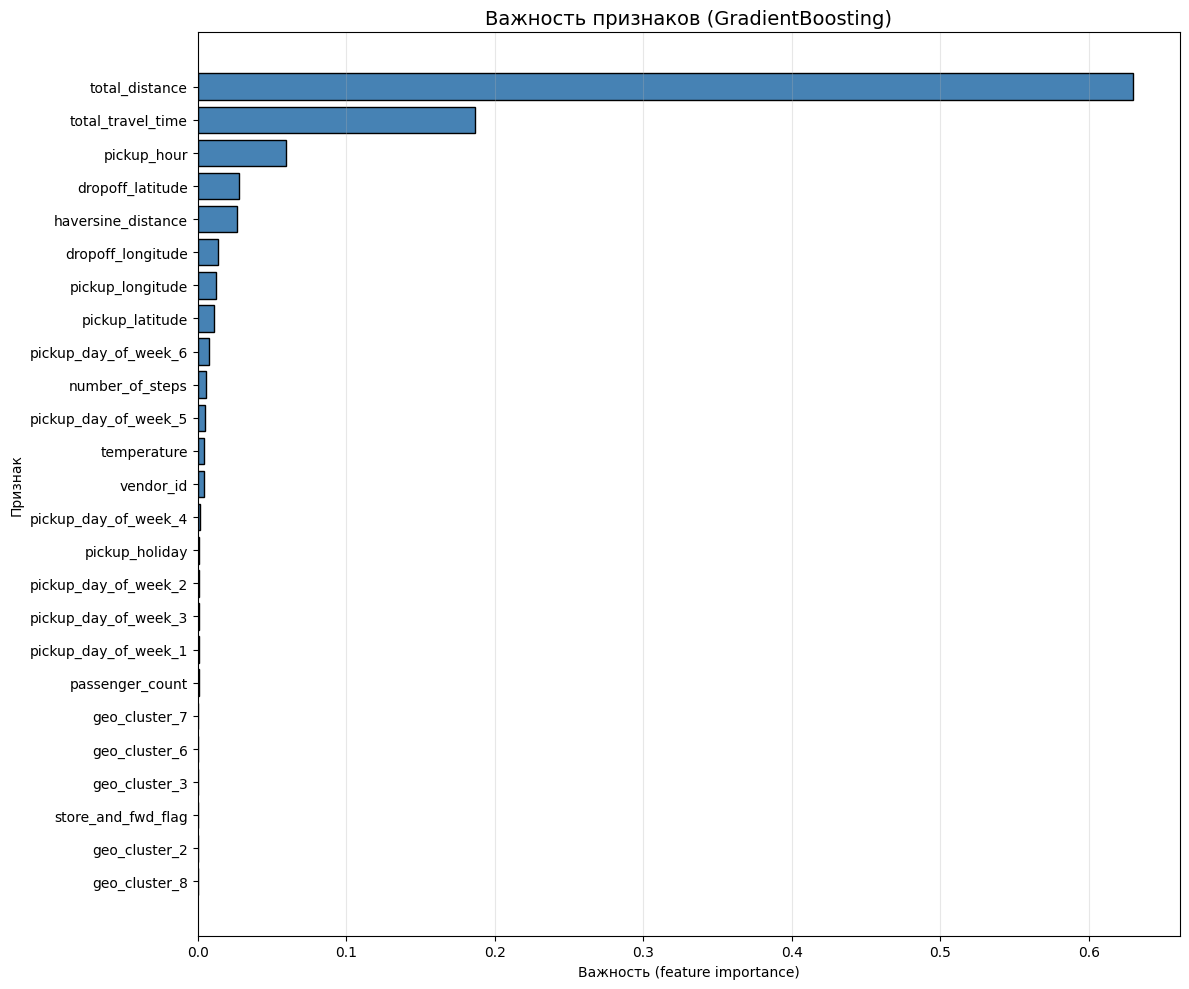


ТОП-3 признака:
  total_distance           : 0.6297
  total_travel_time        : 0.1864
  pickup_hour              : 0.0592

Проверка вариантов A-H:
  A. vendor_id                : ❌ место 13
  B. temperature              : ❌ место 12
  C. total_distance           : ✅ В ТОП-3 (место 1)
  D. total_travel_time        : ✅ В ТОП-3 (место 2)
  E. number_of_steps          : ❌ место 10
  F. pickup_hour              : ✅ В ТОП-3 (место 3)
  G. dropoff_latitude         : ❌ место 4
  H. pickup_latitude          : ❌ место 8


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Получаем важности признаков из обученного GradientBoosting
# ============================================================
feature_importances = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков (топ-25):")
print(feature_importances.to_string(index=False))


# ============================================================
# 2. Столбчатая диаграмма
# ============================================================
plt.figure(figsize=(12, 10))

plt.barh(
    feature_importances['feature'],
    feature_importances['importance'],
    color='steelblue',
    edgecolor='black'
)

plt.title('Важность признаков (GradientBoosting)', fontsize=14)
plt.xlabel('Важность (feature importance)')
plt.ylabel('Признак')
plt.gca().invert_yaxis()   # самые важные — сверху
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


# ============================================================
# 3. Топ-3 признака
# ============================================================
top3 = feature_importances.head(3)
print("\n" + "=" * 50)
print("ТОП-3 признака:")
print("=" * 50)
for i, row in top3.iterrows():
    print(f"  {row['feature']:25s}: {row['importance']:.4f}")


# ============================================================
# 4. Проверка вариантов A-H
# ============================================================
options = {
    'A': 'vendor_id',
    'B': 'temperature',
    'C': 'total_distance',
    'D': 'total_travel_time',
    'E': 'number_of_steps',
    'F': 'pickup_hour',
    'G': 'dropoff_latitude',
    'H': 'pickup_latitude'
}

print("\n" + "=" * 50)
print("Проверка вариантов A-H:")
print("=" * 50)
top3_list = top3['feature'].tolist()
for letter, feat in options.items():
    if feat in top3_list:
        rank = top3_list.index(feat) + 1
        print(f"  {letter}. {feat:25s}: ✅ В ТОП-3 (место {rank})")
    else:
        # Находим реальную позицию
        pos = feature_importances[feature_importances['feature'] == feat].index
        if len(pos) > 0:
            rank = list(feature_importances.index).index(pos[0]) + 1
            print(f"  {letter}. {feat:25s}: ❌ место {rank}")
        else:
            print(f"  {letter}. {feat:25s}: ⚠️ нет в списке")

In [69]:
import numpy as np
from sklearn.metrics import median_absolute_error


# ============================================================
# 1. Обратное преобразование из логарифмического масштаба
#    y = exp(z) - 1
# ============================================================
# Истинные значения (valid)
y_valid_actual = np.exp(y_valid_log) - 1

# Предсказания лучшей модели (GradientBoosting)
y_valid_pred_actual = np.exp(y_valid_pred_gb) - 1

print("Проверка обратного преобразования:")
print(f"  y_valid_log (первые 3):        {y_valid_log.values[:3]}")
print(f"  y_valid_actual (первые 3):     {y_valid_actual.values[:3]}")
print(f"  y_valid_pred_actual (первые 3): {y_valid_pred_actual[:3]}")


# ============================================================
# 2. MeAE в секундах
# ============================================================
meae_seconds = median_absolute_error(y_valid_actual, y_valid_pred_actual)
print(f"\nMeAE (в секундах): {meae_seconds:.2f} сек")


# ============================================================
# 3. Переводим в минуты и округляем
# ============================================================
meae_minutes = meae_seconds / 60
print(f"MeAE (в минутах): {meae_minutes:.1f} мин")


# ============================================================
# 4. Ответ
# ============================================================
print(f"\n{'=' * 50}")
print(f"Ответ: {meae_minutes:.1f} минут")
print(f"{'=' * 50}")

Проверка обратного преобразования:
  y_valid_log (первые 3):        [5.96614674 5.22035583 2.19722458]
  y_valid_actual (первые 3):     [389. 184.   8.]
  y_valid_pred_actual (первые 3): [436.74350562 231.61527134 112.70195394]

MeAE (в секундах): 110.37 сек
MeAE (в минутах): 1.8 мин

Ответ: 1.8 минут
